<a href="https://colab.research.google.com/github/alissonjsb4/applied-computational-intelligence/blob/main/homework1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# HOMEWORK 01 INTELIGÊNCIA COMPUTACIONAL APLICADA

Autores:

Icaro Adriano 609310 (Departamento de Engenharia de Teleinformatica)

Matheus Reis 571954 (Departamento de Engenharia de Teleinformatica)

Alisson Jaime 555083 (Departamento de Engenharia de Teleinformatica)

Vinicius Alexandre Gomes do Nascimento 568594 (Departamento de Engenharia de Teleinformatica)

# DESCRIÇÃO DO DATASET

Como primeiro passo da análise, para conhecer o dataset de original, importa-se o dataset em formato csv, transformando-o em objeto dataframe do pandas, e printa-se o head do dataframe.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('dataset/diabetes_risk_prediction_dataset.csv') # Lê um csv e transforma em um objeto rabela do pandas
saida = 'Diabetes_Risk_Score'

print(df.head()) # printa o head do dataframe

   Patient_ID   Age Gender        Country  Height_cm  Weight_kg   BMI  \
0           1  32.0   Male         Mexico      182.1       65.8  19.8   
1           2  42.0  Other   Saudi Arabia      148.5      101.2  45.9   
2           3  89.0  Other      Argentina      158.1        NaN  37.9   
3           4  87.0  Other  United States      190.9       95.9  26.3   
4           5  27.0  Other      Australia      156.9      101.9  41.4   

   Waist_Circumference_cm  Blood_Glucose  HbA1c  ...  Fatty_Liver  PCOS  \
0                    71.2           88.4   10.4  ...          Yes    No   
1                   121.8          247.3   11.3  ...          Yes   Yes   
2                   131.8          141.9    6.3  ...          Yes    No   
3                    99.1           90.1    7.4  ...           No    No   
4                    77.1           93.8   12.0  ...          Yes   Yes   

   Medication_Adherence   Work_Type  Residence_Type  Daily_Water_Intake_L  \
0                  Good     Retir

Em seguida, contamos o número de observações N, e de preditores D.

In [2]:
rows, columns = df.shape

print('número de linhas N: ', rows)
print('número de colunas: ', columns)


número de linhas N:  50000
número de colunas:  41


A partir dessas informações já nos é possível constatar que o número de observações é de 50000, que corresponde ao numero de linhas de um dataframe pandas, já o número de preditores depende de quantas variáveis queremos predizer, como o dataset não foi um dos contidos no exercício proposto, ainda faremos uma limpeza anterior, mas queremos predizer apenas o atributo Diabetes_Risk_Score, logo nosso número de preditores é inicialmente 40.

Para determinarmos as classes e sua distribuição iremos filtrar apenas os preditores qualitativos, e fazer a contagem dos diferentes valores destes.

In [3]:
preditores = df.drop(columns=[saida]) # Insere a coluna com nome da variavel saida em uma variavel preditores

def print_classes(dataframe):
    preditores_qualitativos = dataframe.select_dtypes(include=['object', 'category', 'string']) # pega os atributos com tipo especificado como argumento

    df_derretido = preditores_qualitativos.melt(var_name='Preditor', value_name='Valor') # transforma atributos em uma nova coluna cujos valores são os nomes dos atributos anteriores
    ocorrencias = df_derretido.value_counts(subset=['Preditor', 'Valor'])
    total_classes = len(ocorrencias)

    print("Distribuição de classes:")
    print(ocorrencias.to_string())
    print("Total de classes L:", total_classes)
    return

print_classes(preditores)

Distribuição de classes:
Preditor                    Valor                              
Doctor_Consultation_Needed  Yes                                    46426
Diabetes_Risk               High                                   36593
Heart_Disease               No                                     25288
Hypertension                Yes                                    25200
Fatty_Liver                 No                                     25155
Residence_Type              Urban                                  25129
Family_History_Diabetes     No                                     25076
PCOS                        No                                     25071
                            Yes                                    24929
Family_History_Diabetes     Yes                                    24924
Residence_Type              Rural                                  24871
Fatty_Liver                 Yes                                    24845
Hypertension                No     

A contagem acima junta os valores distintos de *todas* as colunas qualitativas, o que dá um número
inflado e não é o que o enunciado chama de classe. A classe (o rótulo L) é uma coluna só: a
`Diabetes_Risk`, que classifica cada paciente em `Low`, `Moderate` ou `High`. É ela que usamos como
rótulo nas análises condicionais (item 3), na bivariada (item 4) e no PCA (item 5).

As demais colunas qualitativas são preditores, não classes. Mantemos `Country` e `Gender` como
preditores qualitativos e descartamos o resto. Também tiramos `Patient_ID`, que é só o identificador
da linha e não carrega informação fisiológica.

In [4]:
classe = 'Diabetes_Risk' # rotulo das observacoes (L = 3: Low, Moderate, High)

preditores_quantitativos = preditores.select_dtypes(include=['int','float']).drop(columns=['Patient_ID'])
preditores_qualitativos = preditores[['Country','Gender']]

preditores = pd.concat([preditores_quantitativos, preditores_qualitativos, df[classe]], axis=1)

print(preditores.head())

print('\nDistribuicao da classe', classe, ':')
print(preditores[classe].value_counts())

    Age  Height_cm  Weight_kg   BMI  Waist_Circumference_cm  Blood_Glucose  \
0  32.0      182.1       65.8  19.8                    71.2           88.4   
1  42.0      148.5      101.2  45.9                   121.8          247.3   
2  89.0      158.1        NaN  37.9                   131.8          141.9   
3  87.0      190.9       95.9  26.3                    99.1           90.1   
4  27.0      156.9      101.9  41.4                    77.1           93.8   

   HbA1c  Fasting_Blood_Sugar  Insulin_Level  Blood_Pressure_Systolic  ...  \
0   10.4                149.5           27.4                       94  ...   
1   11.3                199.3           18.3                      148  ...   
2    6.3                219.6           23.9                      101  ...   
3    7.4                217.7           36.7                      120  ...   
4   12.0                153.5           22.3                      190  ...   

     LDL  Triglycerides  Heart_Rate  Exercise_Hours_Per_Week  

Agora extraímos o número de observações N, o número de preditores D e o número de classes L com a sua
distribuição, que é exatamente o que o item 1 do enunciado pede.

In [5]:
rows, columns = preditores.shape

print('Numero de observacoes N: ', rows)
print('Numero de preditores D: ', columns - 1) # -1 porque a coluna de classe nao e preditor
print('Numero de classes L: ', preditores[classe].nunique())
print('\nDistribuicao das classes:')
distribuicao = preditores[classe].value_counts()
for nome, quantidade in distribuicao.items():
    print('  %-10s %6d  (%.2f%%)' % (nome, quantidade, 100 * quantidade / rows))

Numero de observacoes N:  50000
Numero de preditores D:  22
Numero de classes L:  3

Distribuicao das classes:
  High        36593  (73.19%)
  Moderate    12937  (25.87%)
  Low           470  (0.94%)


# ANÁLISE MONOVARIADA INCONDICIONAL
Por seguinte realizaremos uma análise monovariada sem discriminação por classes, extraindo a media, mediana, desvio padrão e assimetría de cada atributo, além de plotar seus histogramas e gráficos de caixa.

Column  Age data: 
Age mean:  53.87109872128962
Age skewness:  0.007512839687922031
Age standart deviation:  21.1301476973126


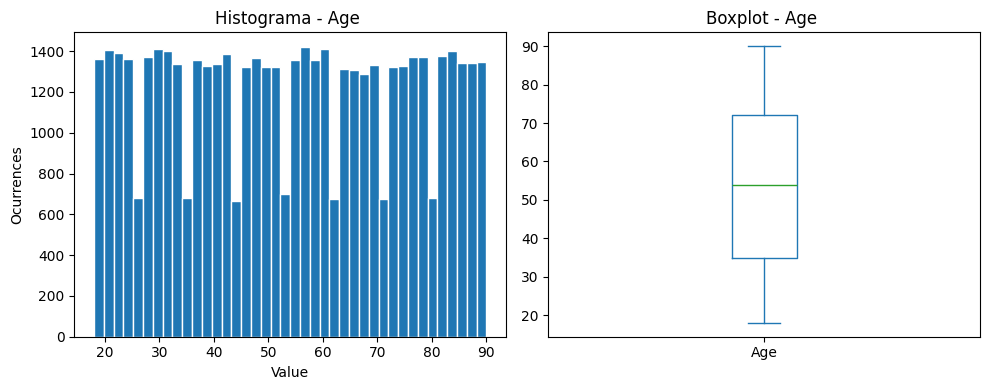

Column  Height_cm data: 
Height_cm mean:  170.01881415365
Height_cm skewness:  0.0004208829320972447
Height_cm standart deviation:  14.457786611277559


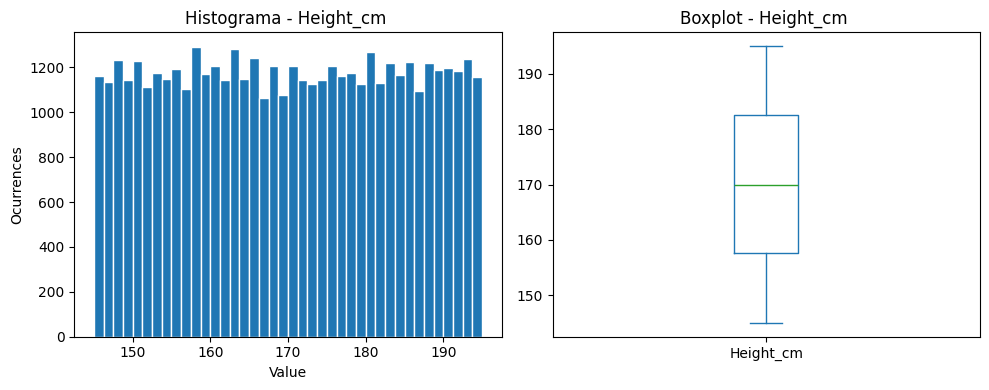

Column  Weight_kg data: 
Weight_kg mean:  87.45700284876058
Weight_kg skewness:  0.004244676677734313
Weight_kg standart deviation:  24.50035783911258


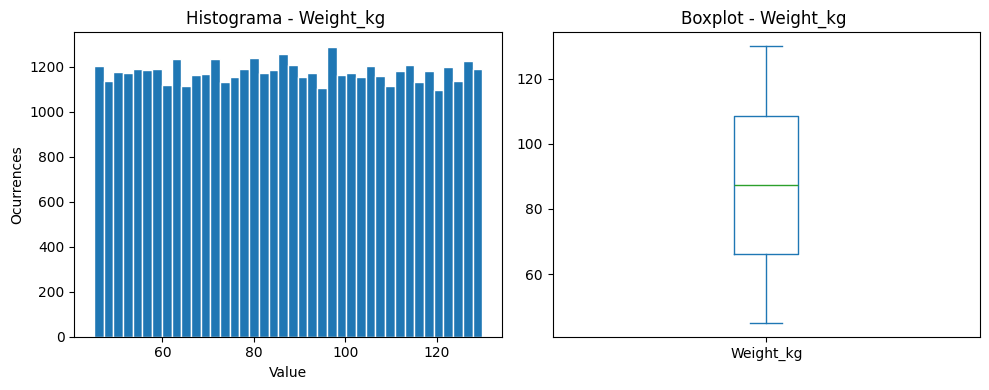

Column  BMI data: 
BMI mean:  30.924055999999997
BMI skewness:  0.4317694129827968
BMI standart deviation:  10.290090661805685


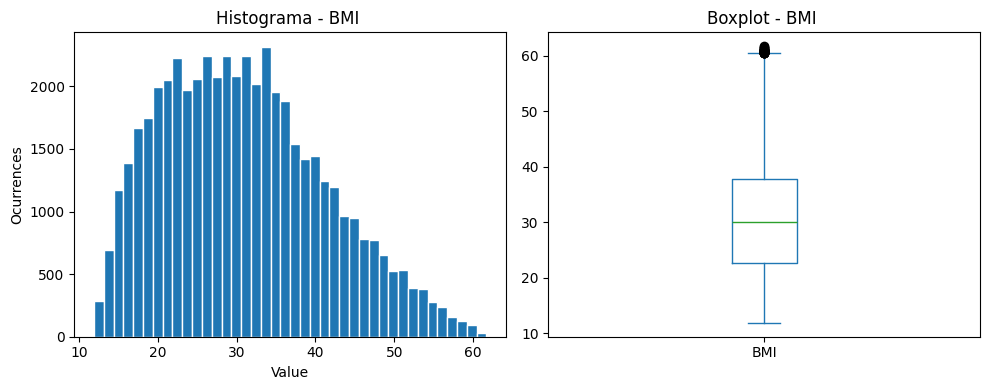

Column  Waist_Circumference_cm data: 
Waist_Circumference_cm mean:  99.96079
Waist_Circumference_cm skewness:  0.009688430624560524
Waist_Circumference_cm standart deviation:  23.08657869365263


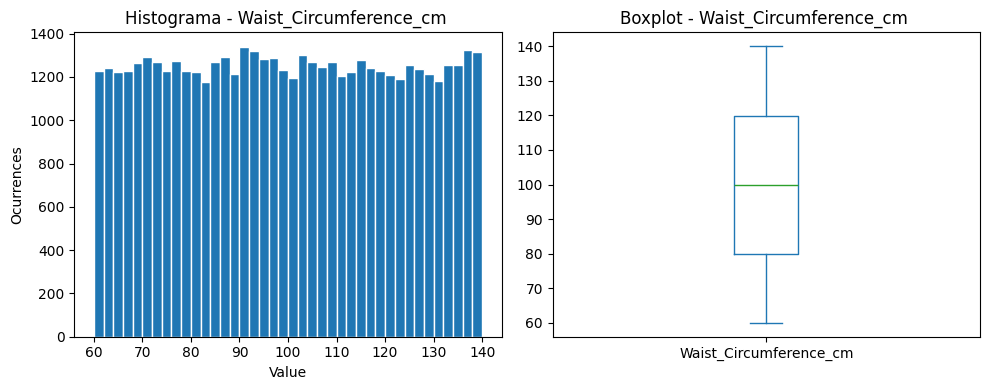

Column  Blood_Glucose data: 
Blood_Glucose mean:  159.90524459126036
Blood_Glucose skewness:  0.006298453438571773
Blood_Glucose standart deviation:  52.04057479292049


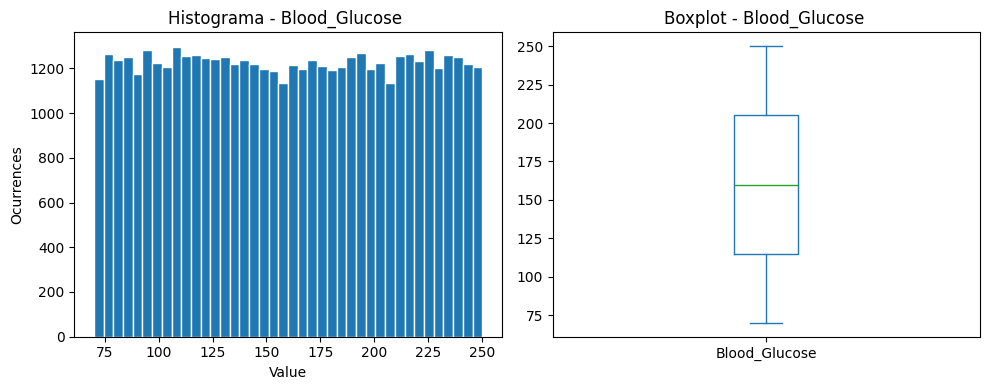

Column  HbA1c data: 
HbA1c mean:  8.488060633823345
HbA1c skewness:  0.001709235175039859
HbA1c standart deviation:  2.313758112953104


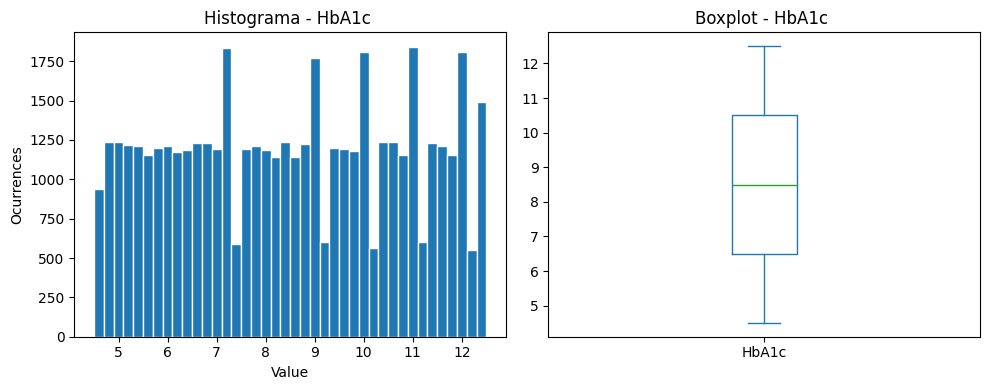

Column  Fasting_Blood_Sugar data: 
Fasting_Blood_Sugar mean:  142.607294
Fasting_Blood_Sugar skewness:  -0.001238050241088894
Fasting_Blood_Sugar standart deviation:  44.681799465348675


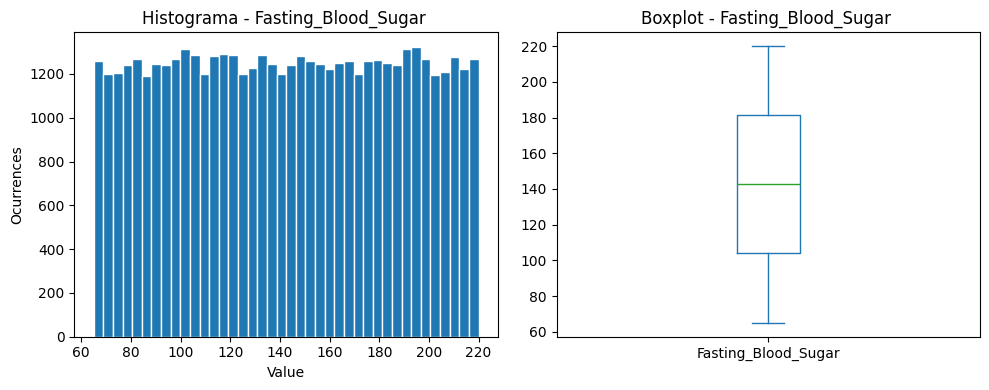

Column  Insulin_Level data: 
Insulin_Level mean:  23.476724
Insulin_Level skewness:  0.005540187089203171
Insulin_Level standart deviation:  12.403841345866477


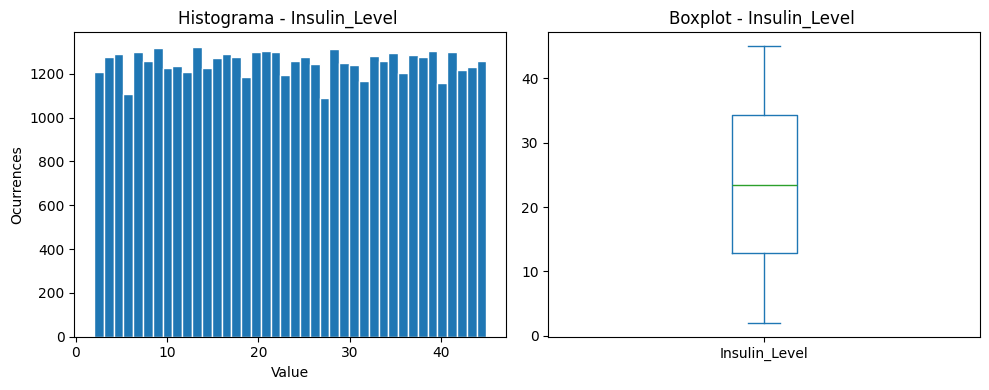

Column  Blood_Pressure_Systolic data: 
Blood_Pressure_Systolic mean:  140.17112
Blood_Pressure_Systolic skewness:  -0.0037586993782831287
Blood_Pressure_Systolic standart deviation:  29.16862310972327


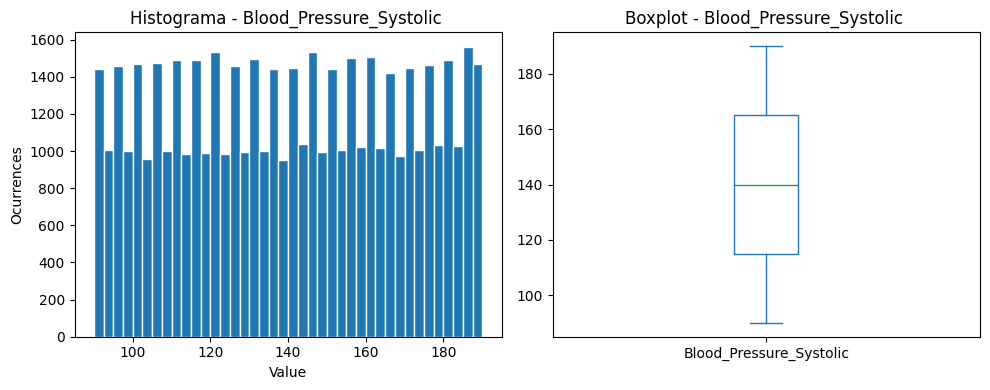

Column  Blood_Pressure_Diastolic data: 
Blood_Pressure_Diastolic mean:  90.039
Blood_Pressure_Diastolic skewness:  -0.009580192888386744
Blood_Pressure_Diastolic standart deviation:  17.575502751441828


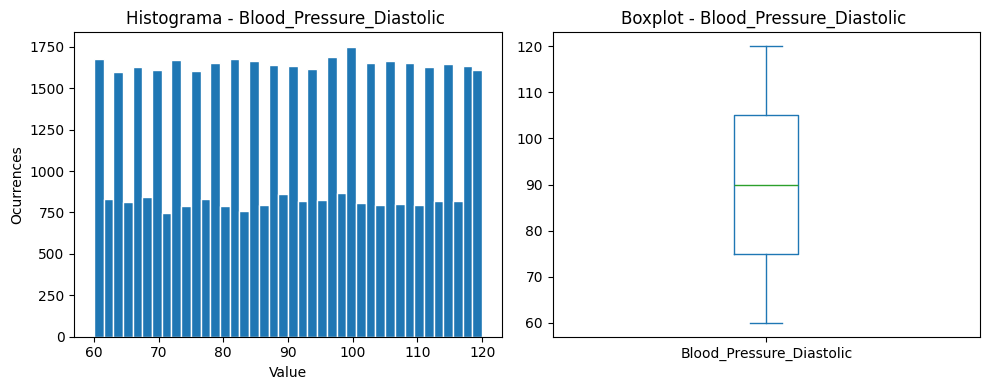

Column  Total_Cholesterol data: 
Total_Cholesterol mean:  220.16863469387755
Total_Cholesterol skewness:  -0.005052912473229835
Total_Cholesterol standart deviation:  57.793626169978666


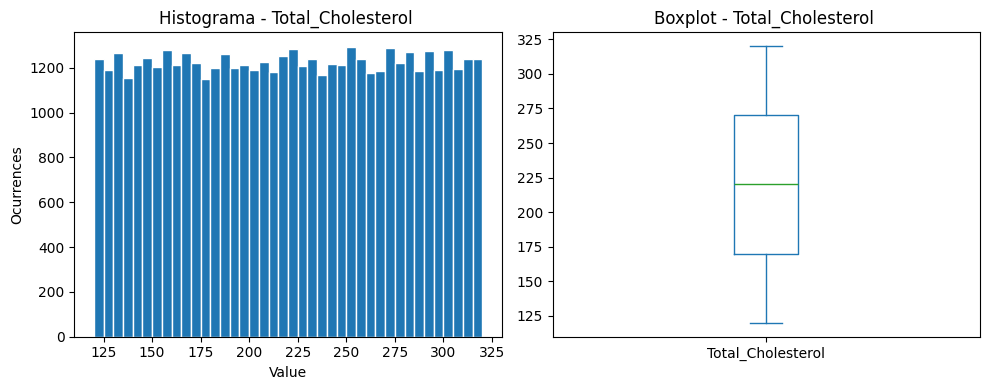

Column  HDL data: 
HDL mean:  57.371730612244896
HDL skewness:  0.003957540464458477
HDL standart deviation:  18.720696124390916


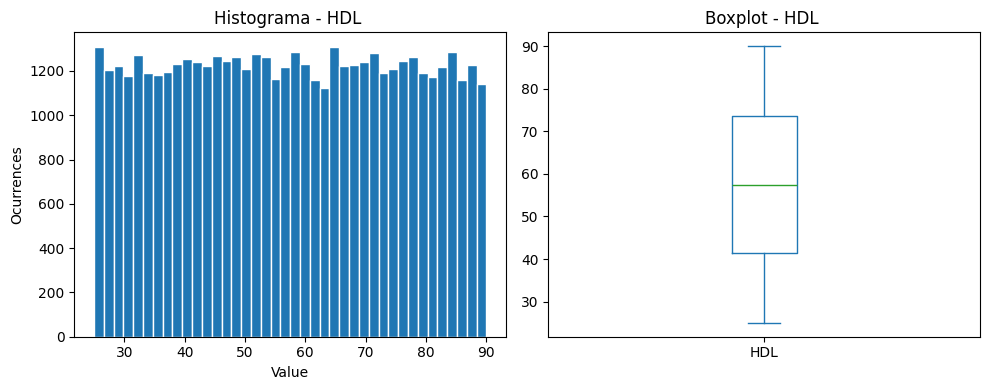

Column  LDL data: 
LDL mean:  135.01452448979592
LDL skewness:  -0.0040724071540167404
LDL standart deviation:  49.13561345314556


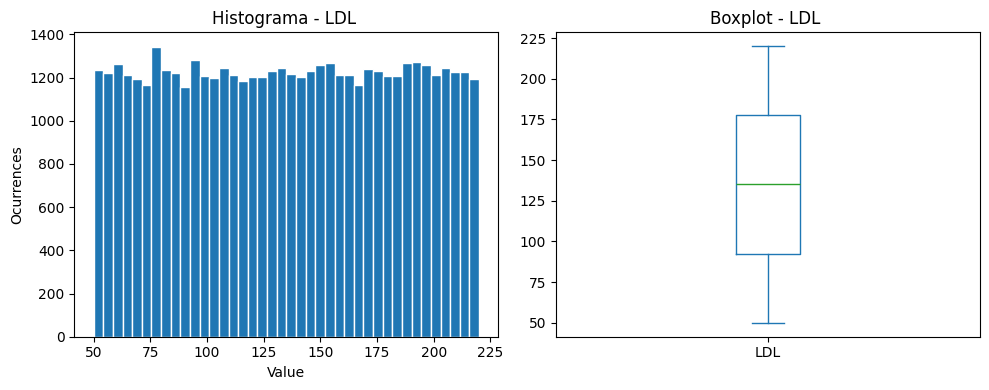

Column  Triglycerides data: 
Triglycerides mean:  229.54325918367346
Triglycerides skewness:  -6.947667438617205e-05
Triglycerides standart deviation:  98.23491079136728


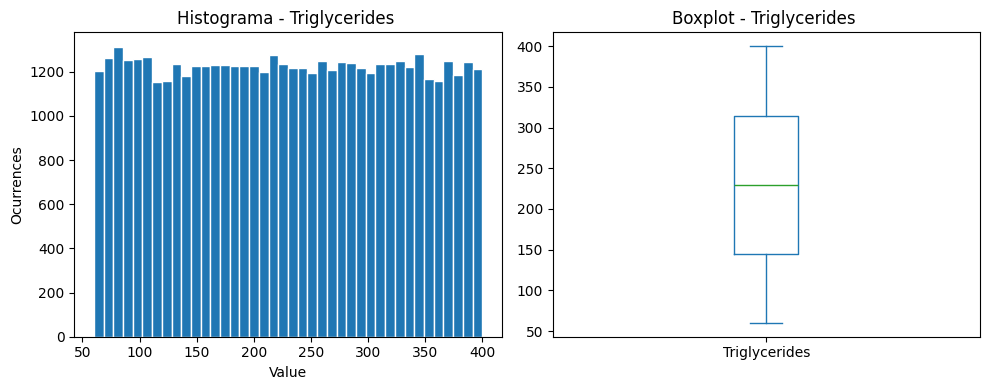

Column  Heart_Rate data: 
Heart_Rate mean:  85.12426
Heart_Rate skewness:  -0.01470155621583733
Heart_Rate standart deviation:  20.390334346623536


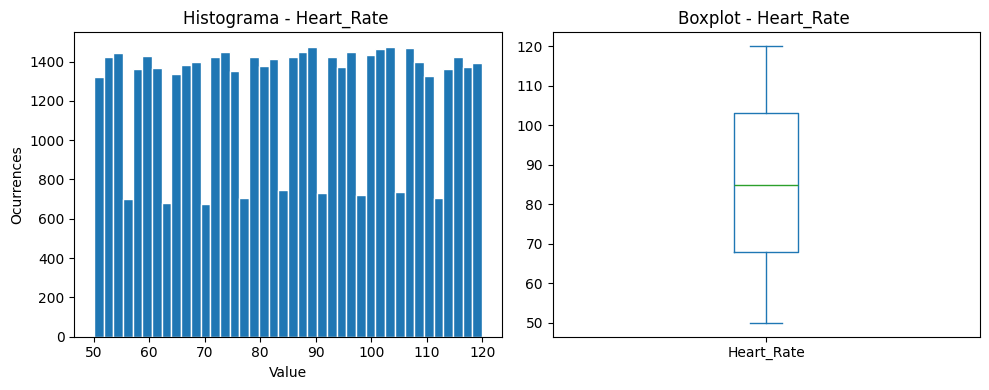

Column  Exercise_Hours_Per_Week data: 
Exercise_Hours_Per_Week mean:  5.017459590068322
Exercise_Hours_Per_Week skewness:  -0.009296615876170682
Exercise_Hours_Per_Week standart deviation:  2.8759219857896814


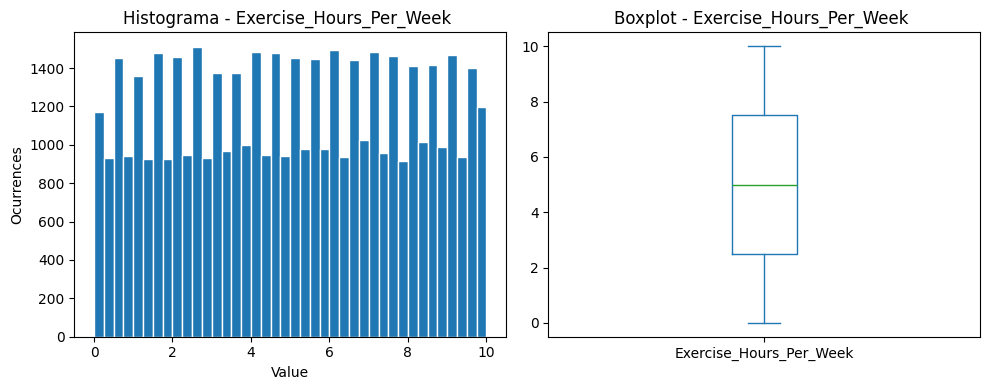

Column  Daily_Walking_Minutes data: 
Daily_Walking_Minutes mean:  89.93344158547754
Daily_Walking_Minutes skewness:  0.0046990351285152235
Daily_Walking_Minutes standart deviation:  52.03464227071244


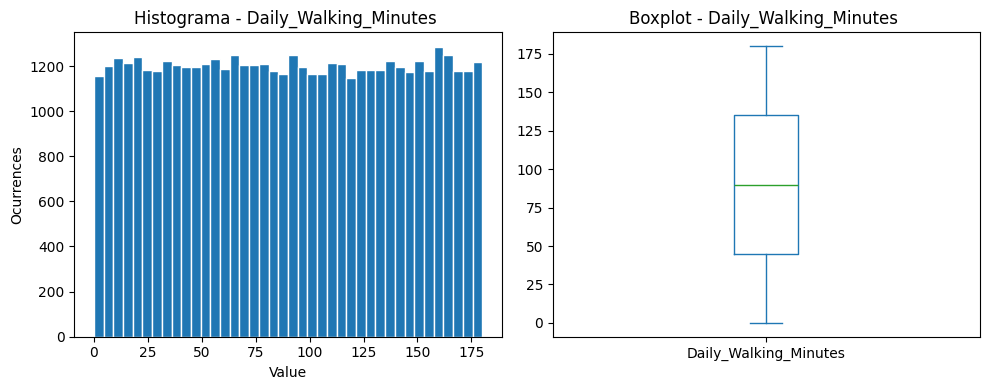

Column  Sleep_Hours data: 
Sleep_Hours mean:  6.500916991434466
Sleep_Hours skewness:  -0.005070828719186202
Sleep_Hours standart deviation:  2.0277929024217074


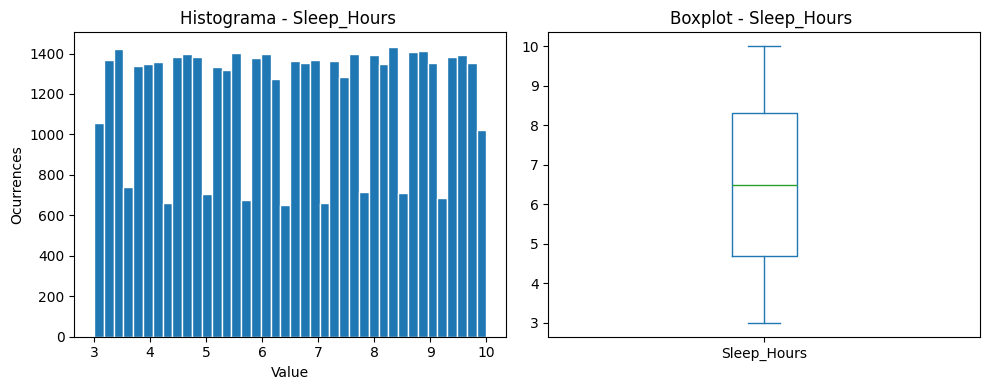

Column  Daily_Water_Intake_L data: 
Daily_Water_Intake_L mean:  2.9988419999999993
Daily_Water_Intake_L skewness:  0.003243961794335443
Daily_Water_Intake_L standart deviation:  1.1522728035010952


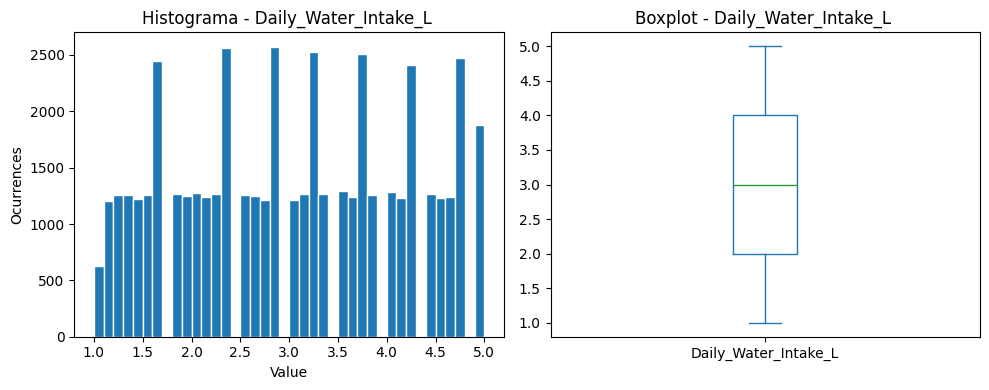

In [6]:
import os

os.makedirs('figuras', exist_ok=True)

def salvar_figura(nome, dpi=120):
    """Salva a figura atual em figuras/<nome>.png para ser usada no artigo."""
    plt.savefig(os.path.join('figuras', nome + '.png'), dpi=dpi, bbox_inches='tight')
    return

import matplotlib.pyplot as plt

def print_statistics(dataframe, column):
    mean = dataframe[column].mean()
    std = dataframe[column].std()
    skewness = dataframe[column].skew()

    
    print(column, 'mean: ', mean)
    print(column, 'skewness: ', skewness)
    print(column, 'standart deviation: ', std)
    return

def plot_hist_and_box(dataframe, column, group=''):
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    
    dataframe[column].plot(kind='hist', ax=axes[0], bins=40, edgecolor='white', title=f'Histograma - {column} {group}')
    axes[0].set_xlabel('Value')
    axes[0].set_ylabel('Ocurrences')
    
    dataframe[column].plot(kind='box', ax=axes[1], title=f'Boxplot - {column} {group}')
    
    plt.tight_layout()
    plt.show()
    return

for columns in preditores_quantitativos:
    print('Column ', columns, 'data: ')
    print_statistics(preditores_quantitativos, columns)
    plot_hist_and_box(preditores_quantitativos, columns)

O enunciado pede que as médias, desvios padrão e assimetrias sejam **tabulados**, e não só impressos
soltos. A tabela abaixo reúne os D = 20 valores de cada estatística da análise incondicional.

In [7]:
tabela_incondicional = pd.DataFrame({
    'media': preditores_quantitativos.mean(),
    'desvio_padrao': preditores_quantitativos.std(),
    'assimetria': preditores_quantitativos.skew(),
}).round(3)

print(tabela_incondicional.to_string())

                            media  desvio_padrao  assimetria
Age                        53.871         21.130       0.008
Height_cm                 170.019         14.458       0.000
Weight_kg                  87.457         24.500       0.004
BMI                        30.924         10.290       0.432
Waist_Circumference_cm     99.961         23.087       0.010
Blood_Glucose             159.905         52.041       0.006
HbA1c                       8.488          2.314       0.002
Fasting_Blood_Sugar       142.607         44.682      -0.001
Insulin_Level              23.477         12.404       0.006
Blood_Pressure_Systolic   140.171         29.169      -0.004
Blood_Pressure_Diastolic   90.039         17.576      -0.010
Total_Cholesterol         220.169         57.794      -0.005
HDL                        57.372         18.721       0.004
LDL                       135.015         49.136      -0.004
Triglycerides             229.543         98.235      -0.000
Heart_Rate              

# ANÁLISE MONOVARIADA CONDICIONAL

Agora repetimos a análise separando as observações por classe, ou seja, usando só as N_l observações
de cada nível de `Diabetes_Risk`. São os 20 preditores quantitativos x L = 3 classes, o que dá as 60 combinações
de histograma, boxplot, média, desvio padrão e assimetria que o item 3 pede.

ANALISE CONDICIONAL NA CLASSE Diabetes_Risk 

===== Diabetes_Risk = High  (N_l = 36593) =====

Age mean:  56.52692413793103
Age skewness:  -0.1544375572847456
Age standart deviation:  20.715034243646592


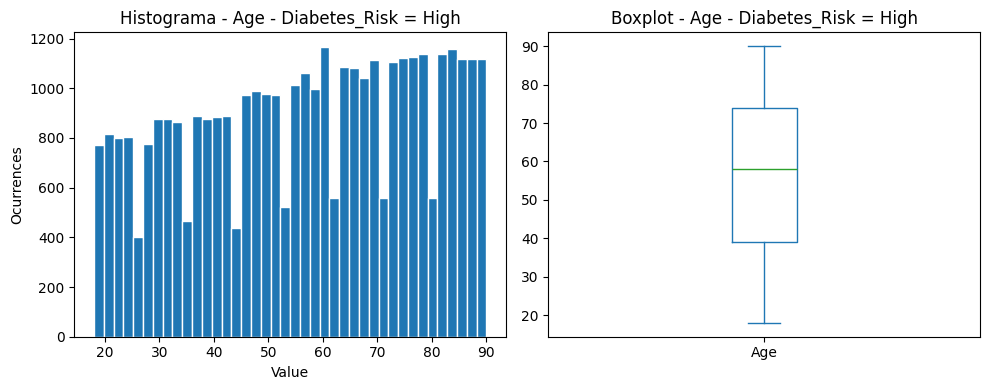

Height_cm mean:  169.3538246838203
Height_cm skewness:  0.05594966429157677
Height_cm standart deviation:  14.431340174754556


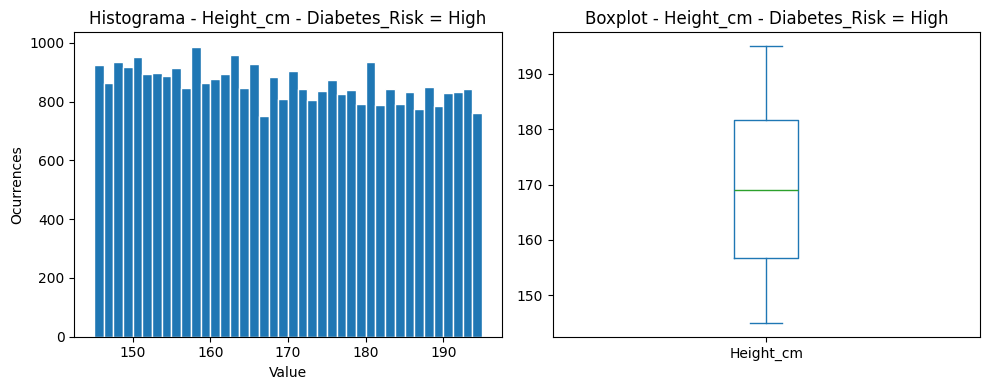

Weight_kg mean:  89.61333526850508
Weight_kg skewness:  -0.109076826219366
Weight_kg standart deviation:  24.32748080276695


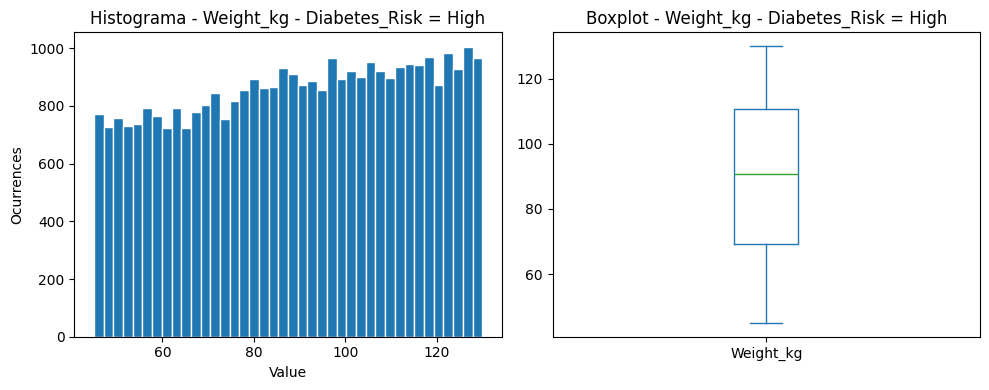

BMI mean:  31.918181072882792
BMI skewness:  0.324659922338471
BMI standart deviation:  10.289592837534869


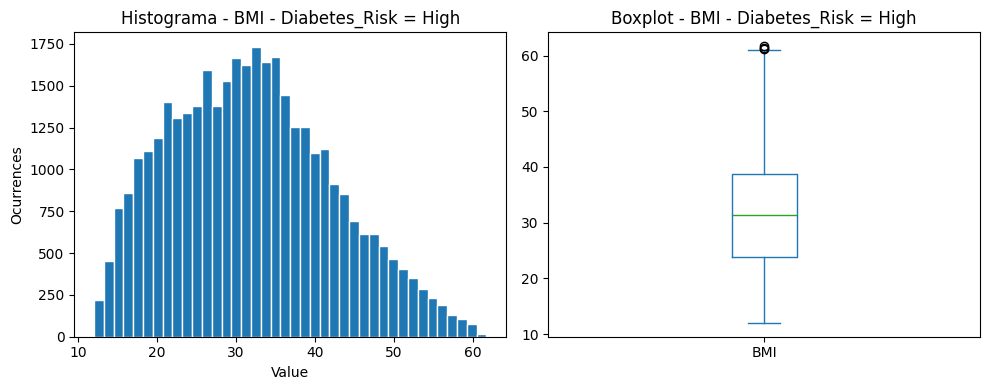

Waist_Circumference_cm mean:  99.90552291421857
Waist_Circumference_cm skewness:  0.012434865542280845
Waist_Circumference_cm standart deviation:  23.09554282845902


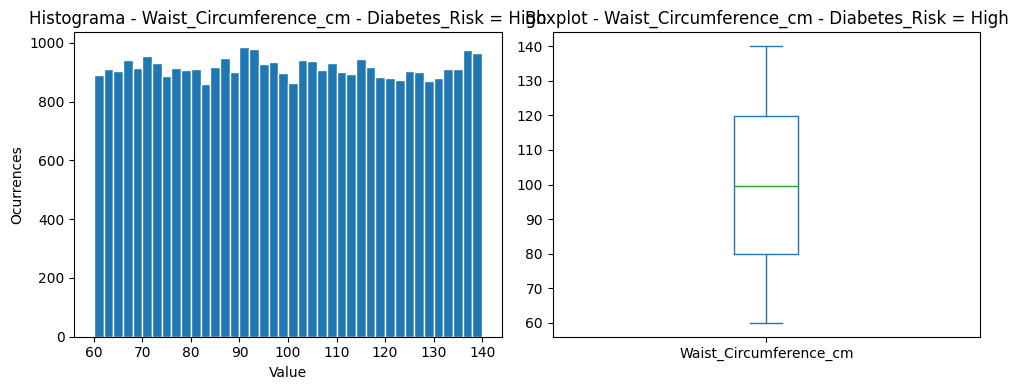

Blood_Glucose mean:  160.07407582806363
Blood_Glucose skewness:  0.00022717874028101357
Blood_Glucose standart deviation:  52.02548055203851


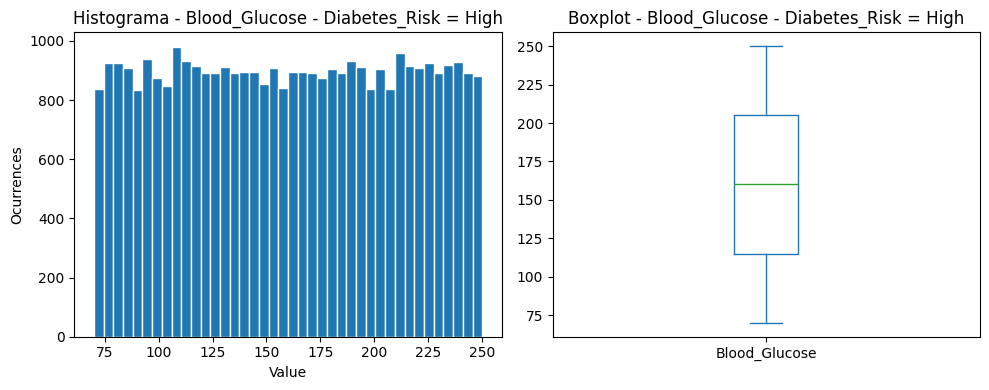

HbA1c mean:  8.858594883760635
HbA1c skewness:  -0.1174206801255776
HbA1c standart deviation:  2.158643081343241


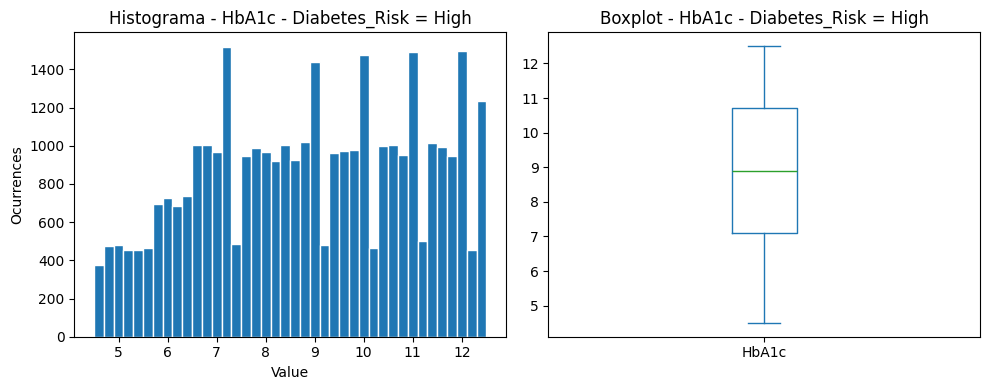

Fasting_Blood_Sugar mean:  152.77577678791025
Fasting_Blood_Sugar skewness:  -0.24182664250851368
Fasting_Blood_Sugar standart deviation:  41.04462508109003


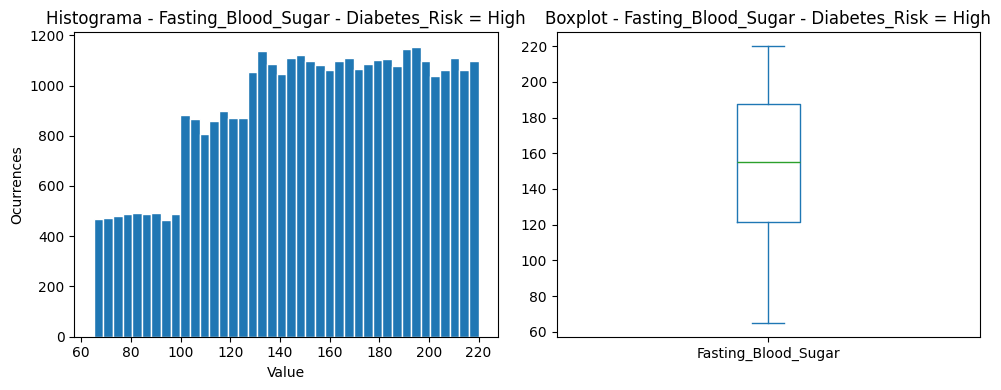

Insulin_Level mean:  23.435687153280686
Insulin_Level skewness:  0.009993933778719467
Insulin_Level standart deviation:  12.40278793722294


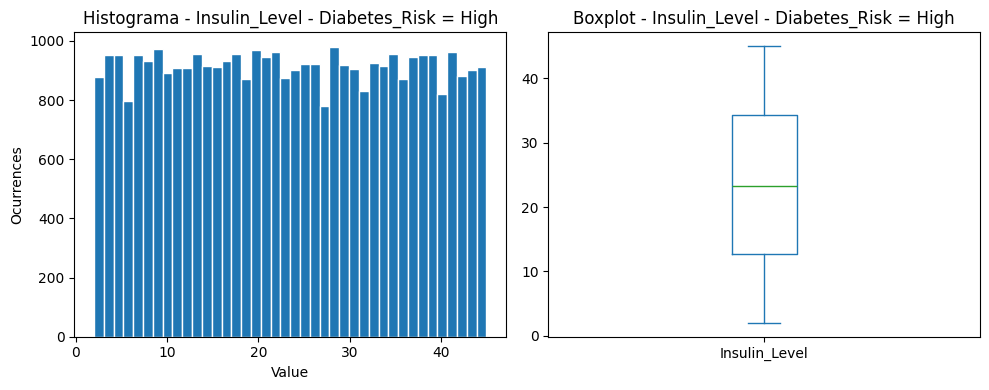

Blood_Pressure_Systolic mean:  142.25149618779548
Blood_Pressure_Systolic skewness:  -0.1053324377299818
Blood_Pressure_Systolic standart deviation:  29.079869095922323


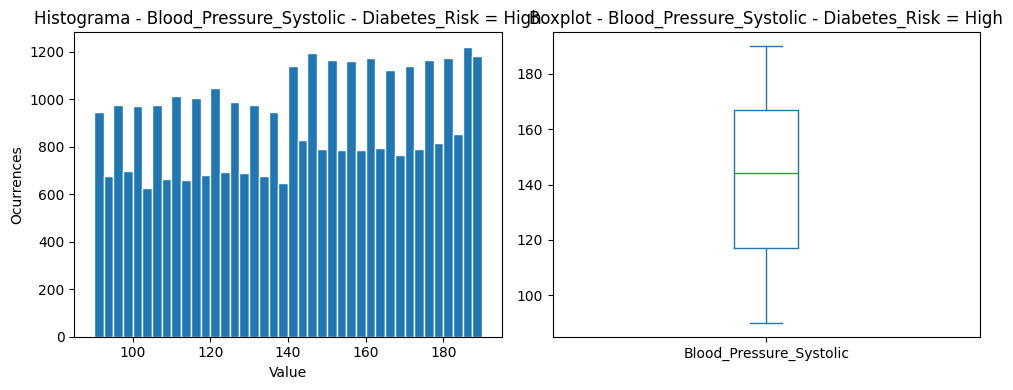

Blood_Pressure_Diastolic mean:  90.79692837427923
Blood_Pressure_Diastolic skewness:  -0.07157176583420694
Blood_Pressure_Diastolic standart deviation:  17.53831926128151


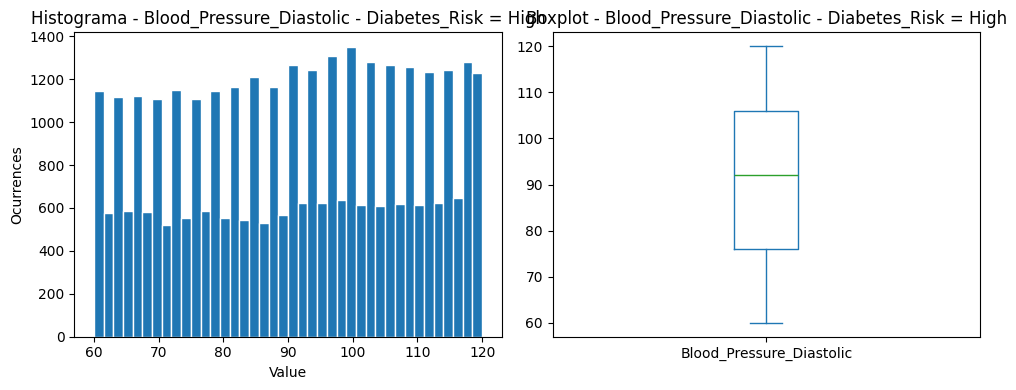

Total_Cholesterol mean:  223.37463743864348
Total_Cholesterol skewness:  -0.08692540095412139
Total_Cholesterol standart deviation:  57.60083587303689


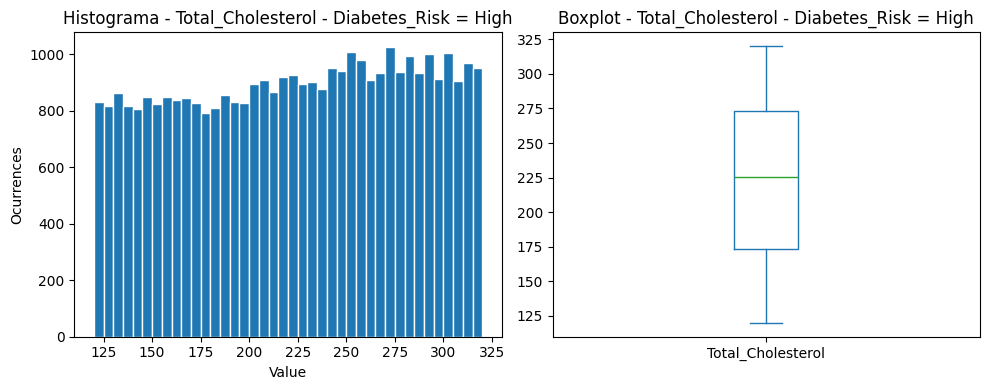

HDL mean:  57.39694048149799
HDL skewness:  0.00391956132889926
HDL standart deviation:  18.68674471862721


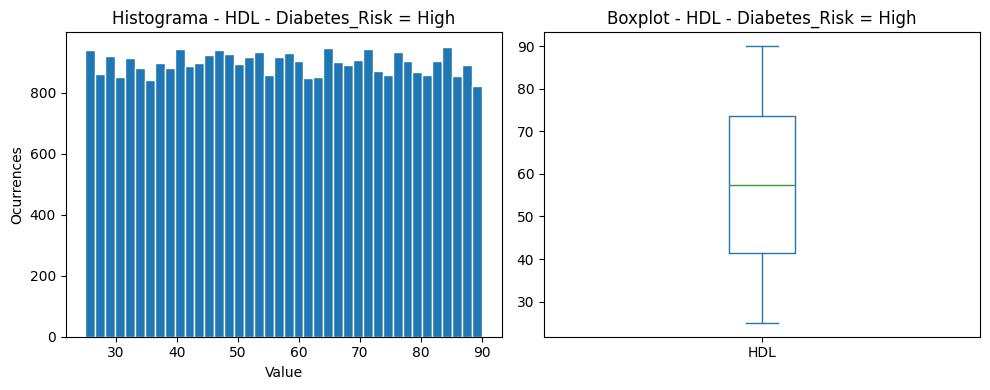

LDL mean:  134.89653941607875
LDL skewness:  -0.0028748839211301816
LDL standart deviation:  49.10341614256115


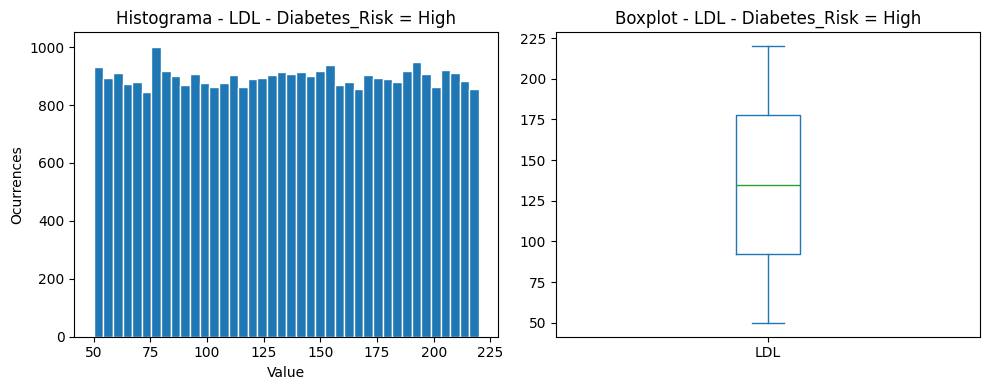

Triglycerides mean:  229.56901914875826
Triglycerides skewness:  -3.7486619231037865e-05
Triglycerides standart deviation:  98.16090420565419


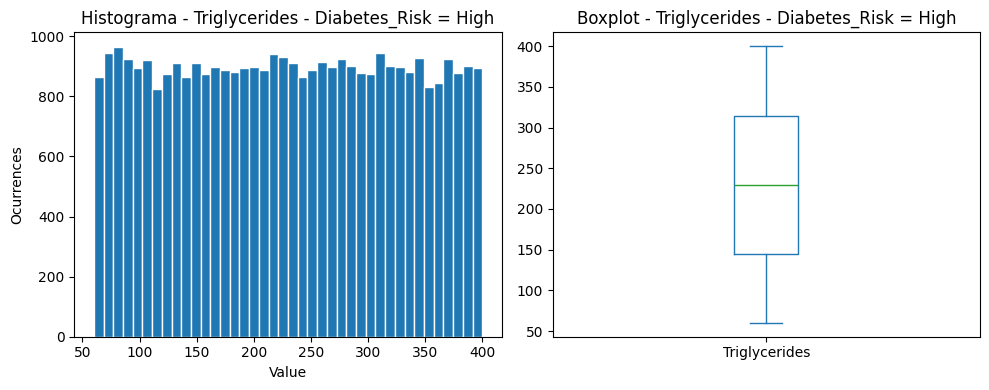

Heart_Rate mean:  85.12986090235837
Heart_Rate skewness:  -0.015346784382783219
Heart_Rate standart deviation:  20.37535754659846


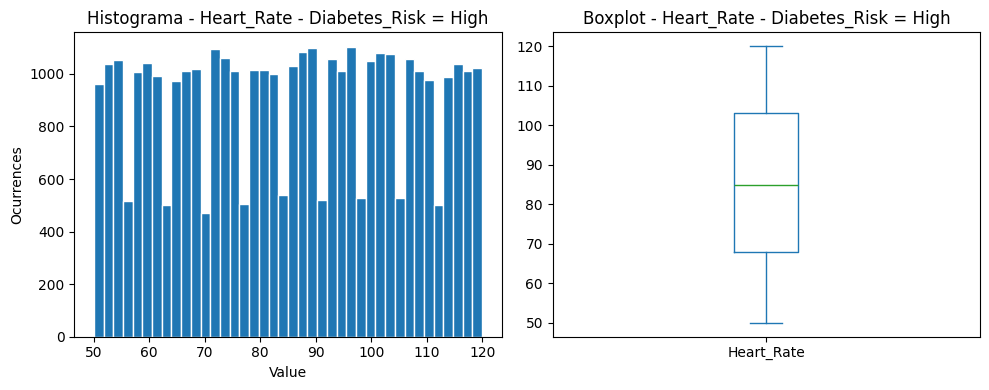

Exercise_Hours_Per_Week mean:  5.017951419540394
Exercise_Hours_Per_Week skewness:  -0.00422155286724284
Exercise_Hours_Per_Week standart deviation:  2.879058486993989


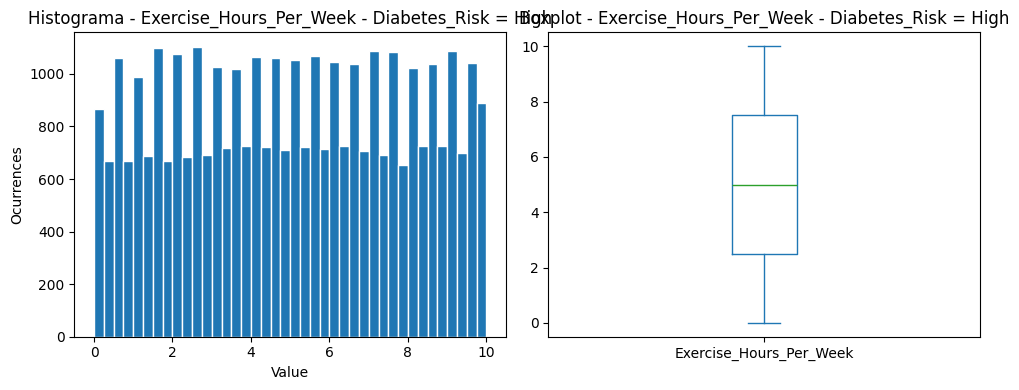

Daily_Walking_Minutes mean:  89.80767326028179
Daily_Walking_Minutes skewness:  0.004022405983854269
Daily_Walking_Minutes standart deviation:  52.027320890727104


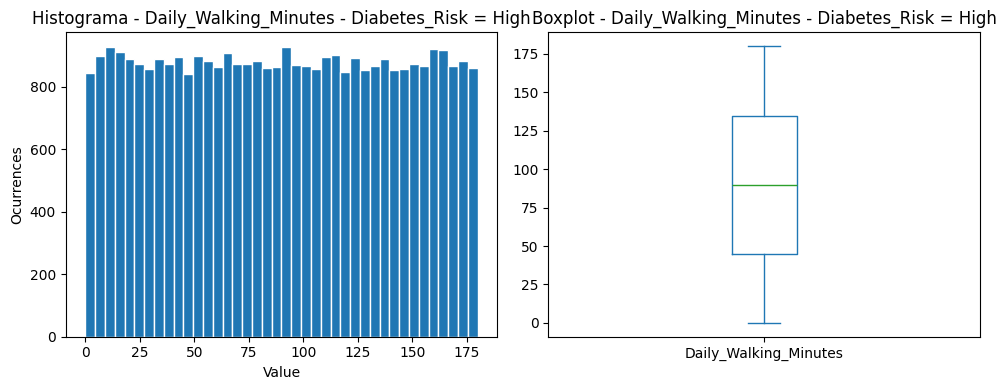

Sleep_Hours mean:  6.439519712853237
Sleep_Hours skewness:  0.036014498325213466
Sleep_Hours standart deviation:  2.035923454344335


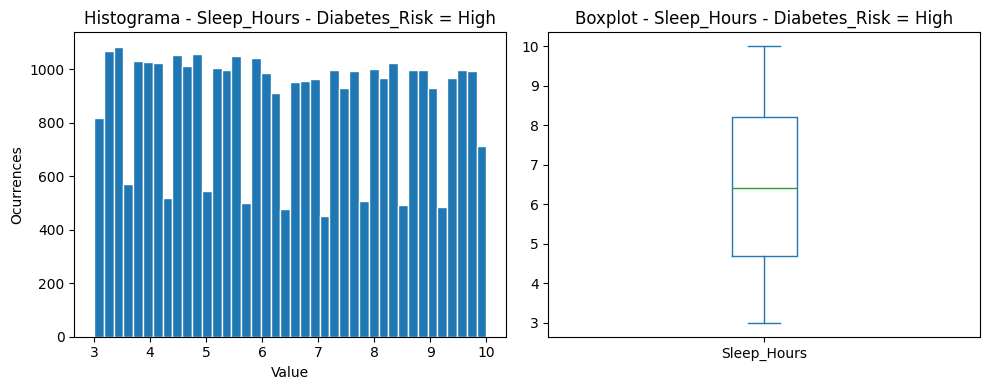

Daily_Water_Intake_L mean:  3.0064411226190804
Daily_Water_Intake_L skewness:  -0.0020388992658812695
Daily_Water_Intake_L standart deviation:  1.151758980476844


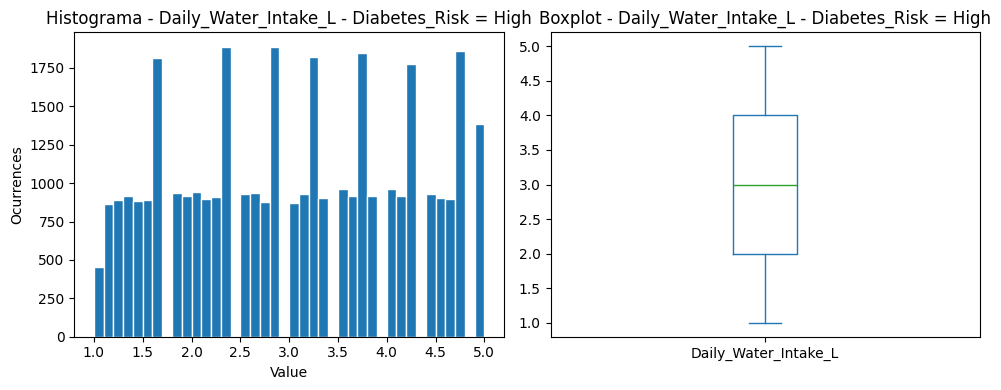

===== Diabetes_Risk = Low  (N_l = 470) =====

Age mean:  38.81330472103004
Age skewness:  0.9595186327905607
Age standart deviation:  17.10151584243619


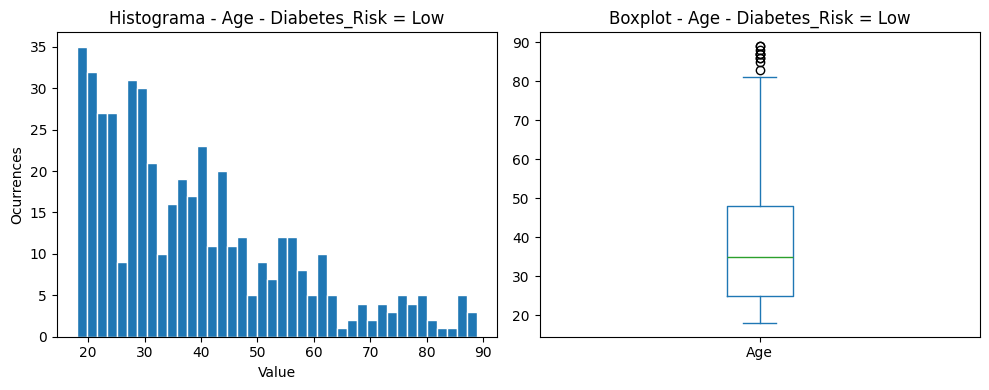

Height_cm mean:  173.66255605381167
Height_cm skewness:  -0.2706752354435558
Height_cm standart deviation:  13.65865776271129


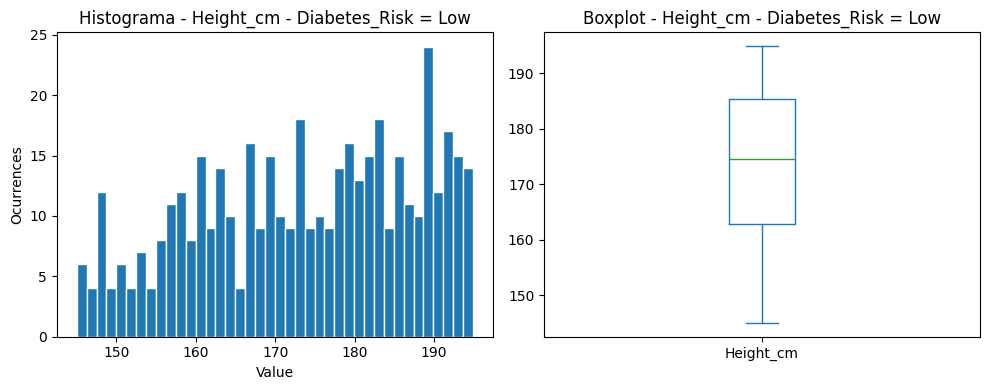

Weight_kg mean:  75.67709750566893
Weight_kg skewness:  0.6241788505986126
Weight_kg standart deviation:  23.133380971936287


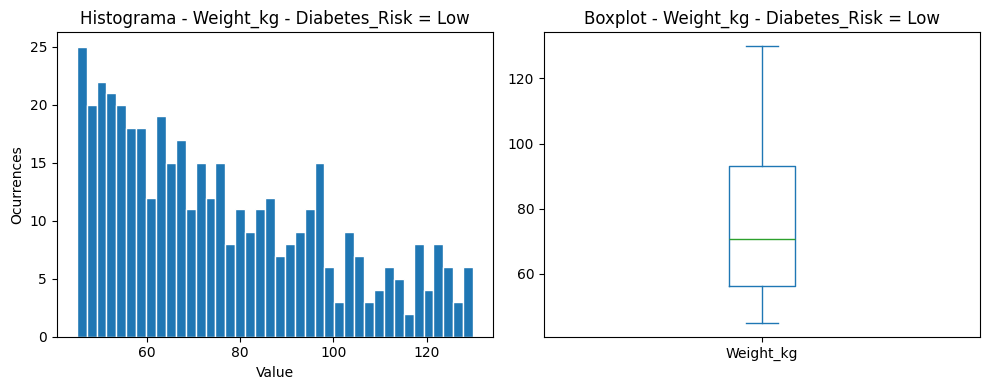

BMI mean:  25.59744680851064
BMI skewness:  1.233171553568634
BMI standart deviation:  9.220705001071275


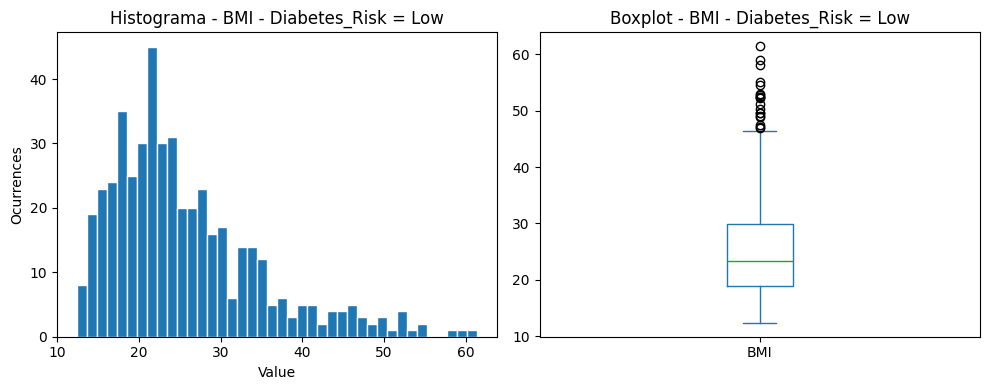

Waist_Circumference_cm mean:  100.84617021276595
Waist_Circumference_cm skewness:  -0.07105929801280468
Waist_Circumference_cm standart deviation:  22.70941813144098


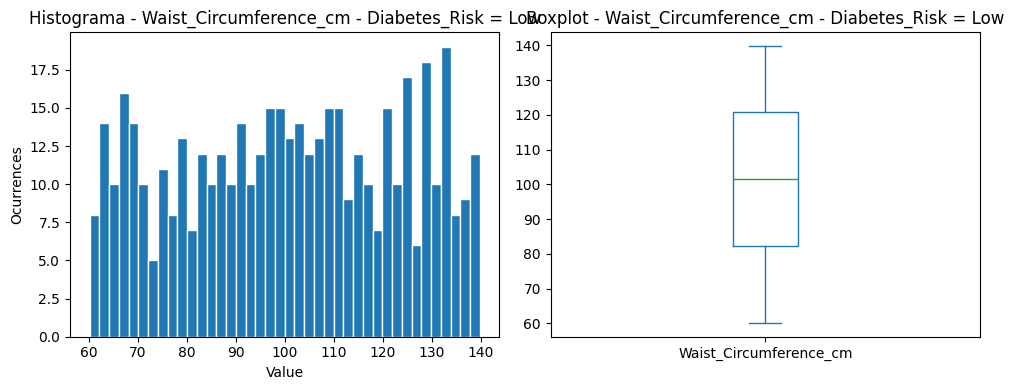

Blood_Glucose mean:  159.0119825708061
Blood_Glucose skewness:  0.018166520495426237
Blood_Glucose standart deviation:  50.9606159279414


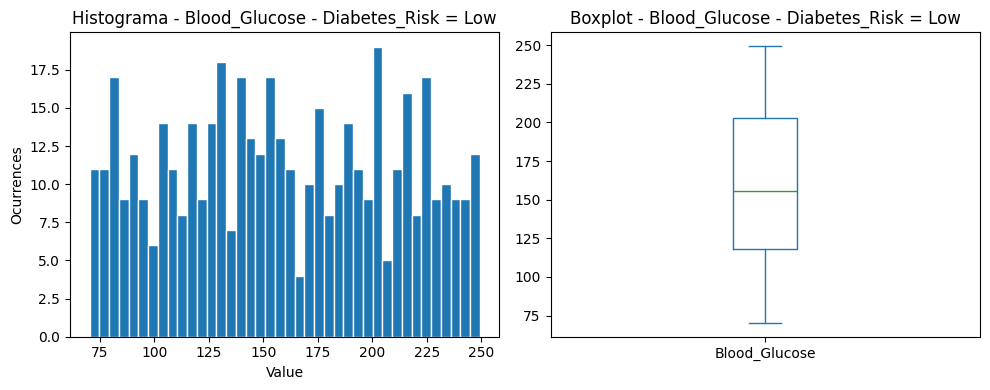

HbA1c mean:  5.673451327433628
HbA1c skewness:  2.732177390193191
HbA1c standart deviation:  1.5720687120223917


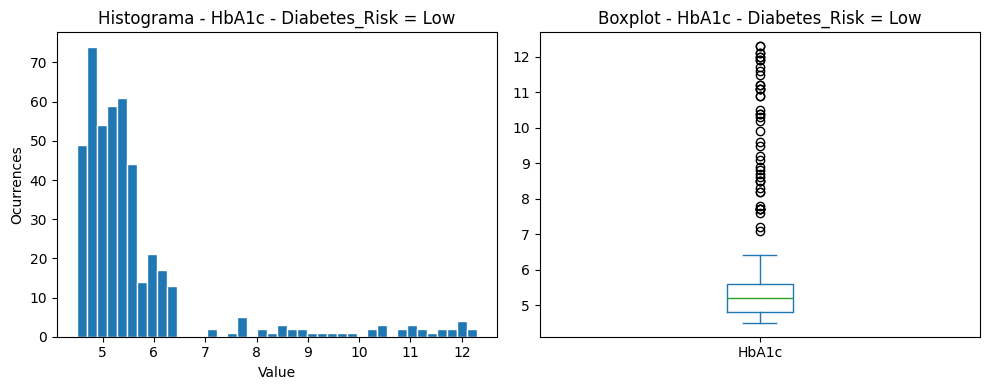

Fasting_Blood_Sugar mean:  88.44191489361702
Fasting_Blood_Sugar skewness:  2.926518174674039
Fasting_Blood_Sugar standart deviation:  20.795715908891356


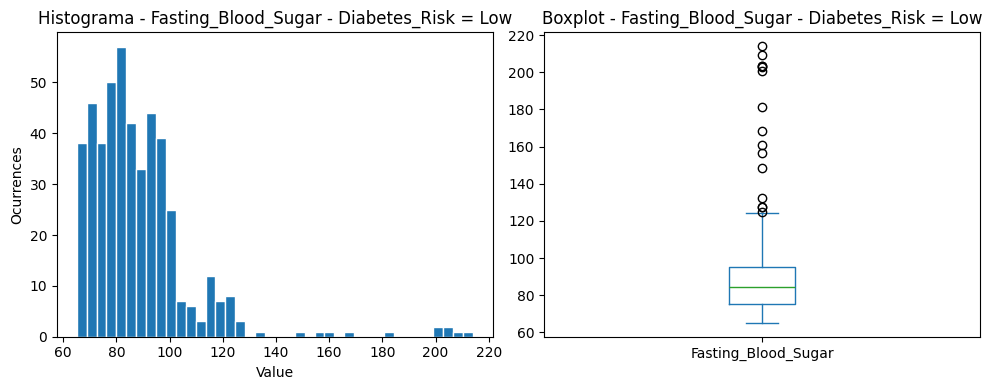

Insulin_Level mean:  23.05191489361702
Insulin_Level skewness:  0.043647710471012985
Insulin_Level standart deviation:  12.334099358540326


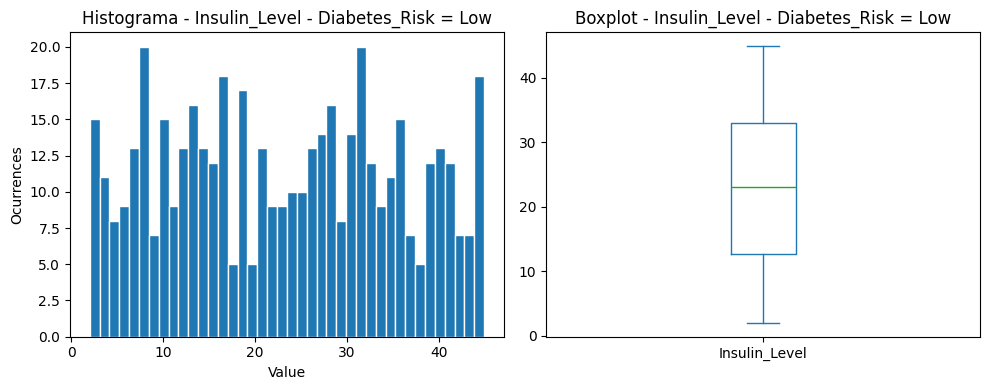

Blood_Pressure_Systolic mean:  127.97659574468085
Blood_Pressure_Systolic skewness:  0.6686279156334174
Blood_Pressure_Systolic standart deviation:  27.332616884272397


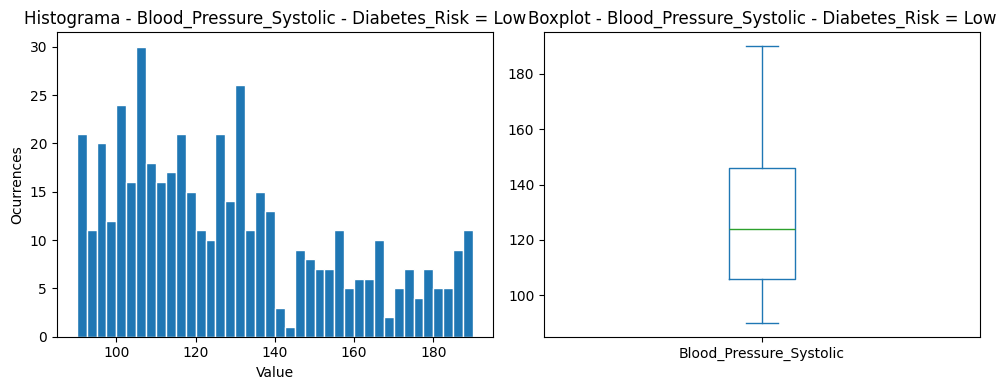

Blood_Pressure_Diastolic mean:  85.54893617021277
Blood_Pressure_Diastolic skewness:  0.33808459505931404
Blood_Pressure_Diastolic standart deviation:  16.63340939297463


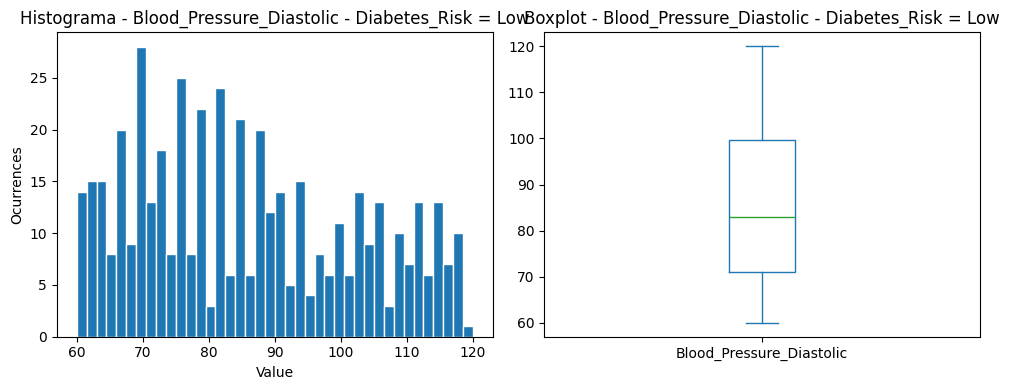

Total_Cholesterol mean:  200.40887445887444
Total_Cholesterol skewness:  0.5161168708743799
Total_Cholesterol standart deviation:  56.91866125590314


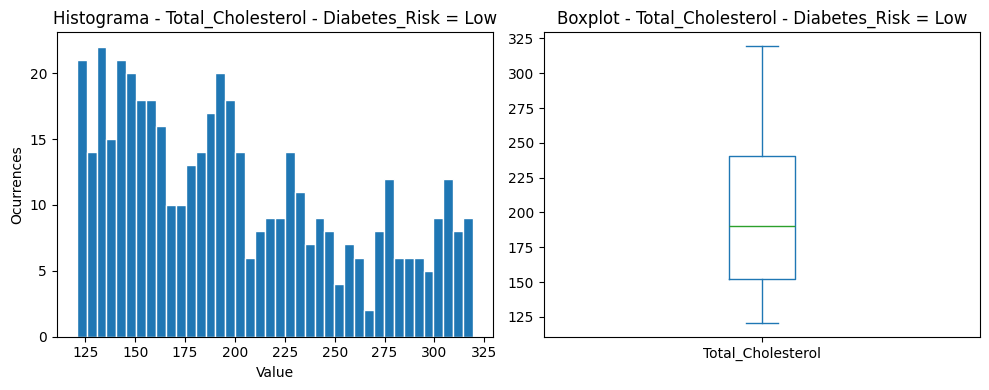

HDL mean:  58.678213507625266
HDL skewness:  -0.1483466296581431
HDL standart deviation:  18.483232229709493


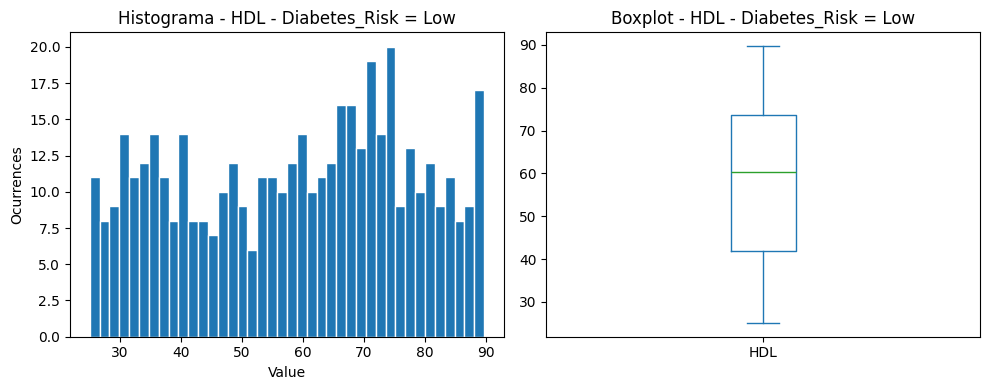

LDL mean:  135.03844492440606
LDL skewness:  0.046144144148369544
LDL standart deviation:  50.157034692834834


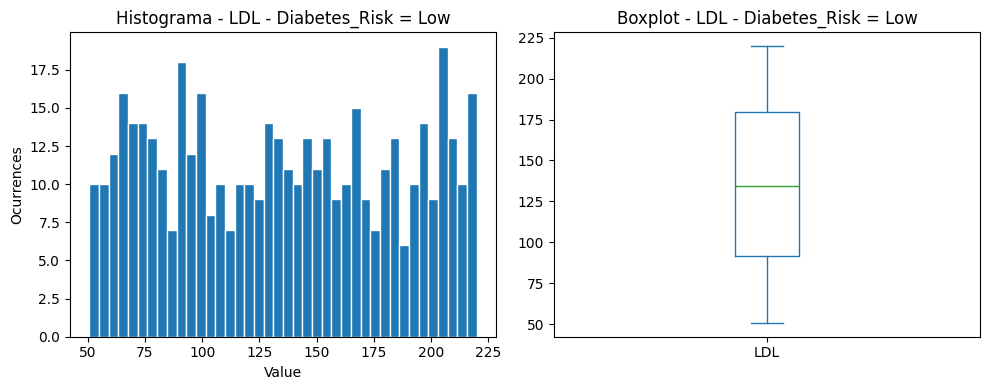

Triglycerides mean:  229.4669546436285
Triglycerides skewness:  0.0014732074811025604
Triglycerides standart deviation:  99.6322248370833


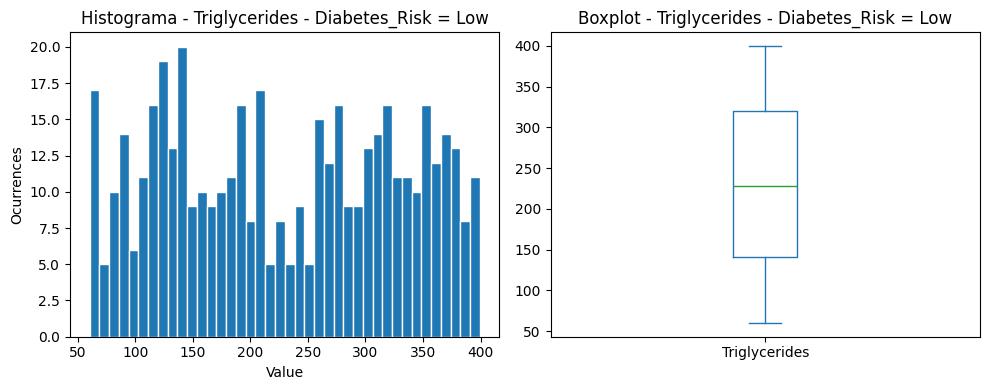

Heart_Rate mean:  85.36170212765957
Heart_Rate skewness:  -0.03190719452948813
Heart_Rate standart deviation:  20.493511929674778


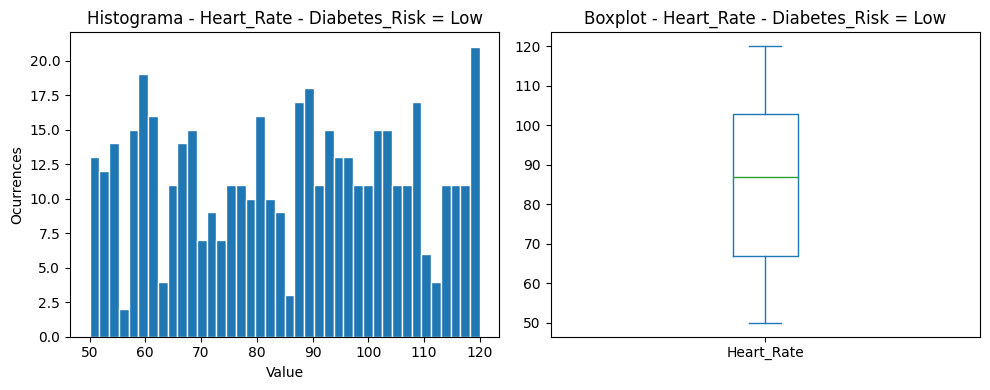

Exercise_Hours_Per_Week mean:  5.033856502242152
Exercise_Hours_Per_Week skewness:  -0.004127038370927706
Exercise_Hours_Per_Week standart deviation:  2.951548352685167


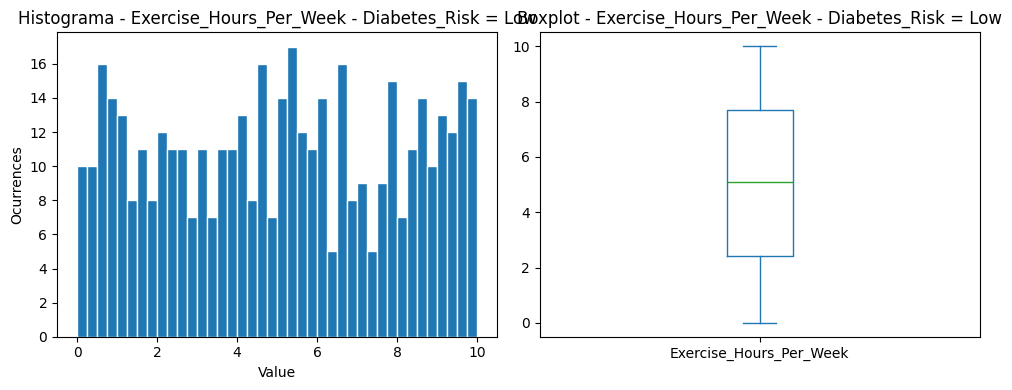

Daily_Walking_Minutes mean:  91.20308370044052
Daily_Walking_Minutes skewness:  -0.01023278129706354
Daily_Walking_Minutes standart deviation:  51.93705852149256


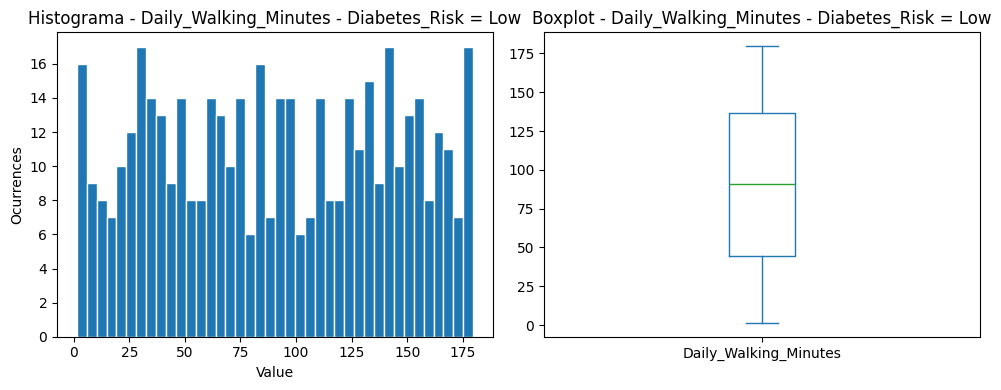

Sleep_Hours mean:  6.77511013215859
Sleep_Hours skewness:  -0.18380288911975864
Sleep_Hours standart deviation:  1.9655469243714185


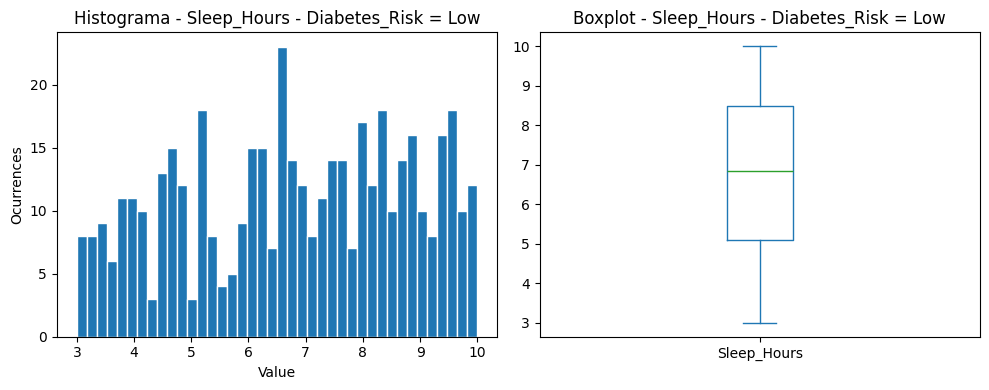

Daily_Water_Intake_L mean:  2.9387234042553194
Daily_Water_Intake_L skewness:  0.0073468190163732405
Daily_Water_Intake_L standart deviation:  1.147143698642822


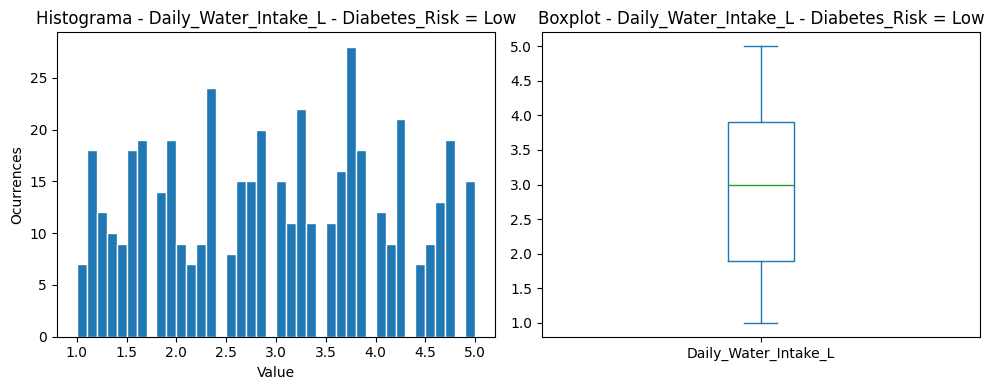

===== Diabetes_Risk = Moderate  (N_l = 12937) =====

Age mean:  46.89082662078674
Age skewness:  0.46659022115691506
Age standart deviation:  20.601254052624952


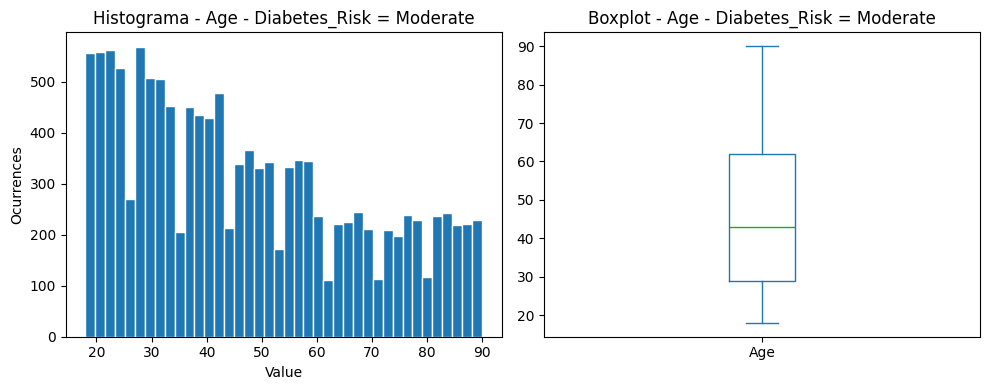

Height_cm mean:  171.7583920091698
Height_cm skewness:  -0.14605407469536327
Height_cm standart deviation:  14.397065540510896


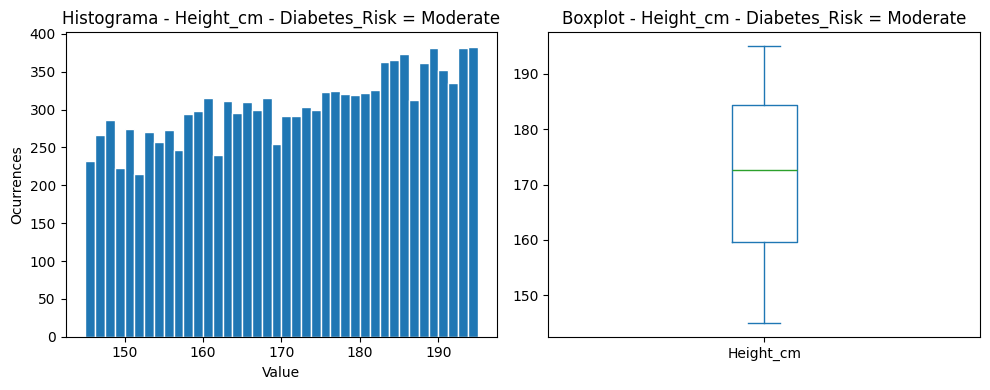

Weight_kg mean:  81.76911994731209
Weight_kg skewness:  0.31020714846403574
Weight_kg standart deviation:  24.00177563360609


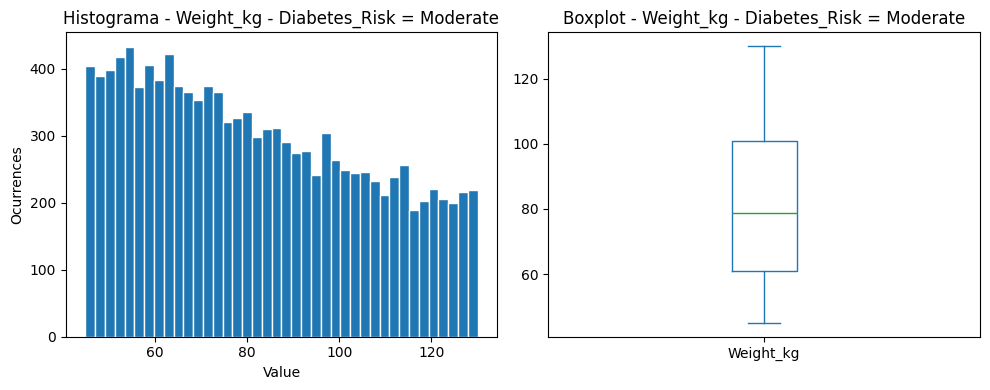

BMI mean:  28.305635000386488
BMI skewness:  0.7589295046077944
BMI standart deviation:  9.798194711520088


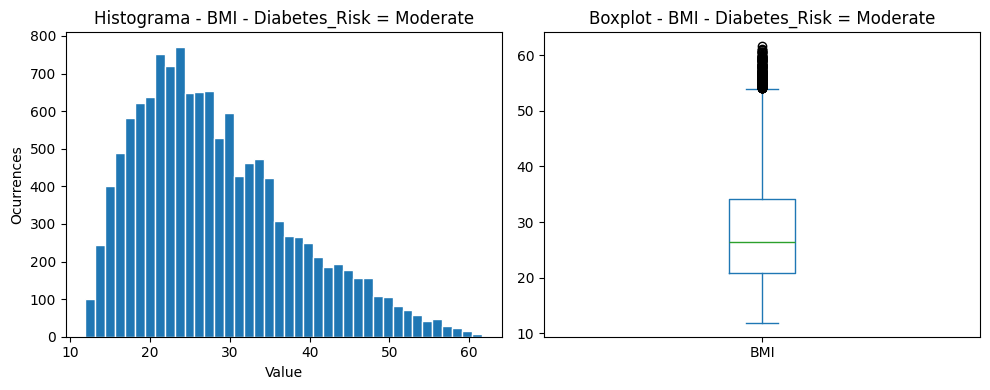

Waist_Circumference_cm mean:  100.0849501430007
Waist_Circumference_cm skewness:  0.004855180586632266
Waist_Circumference_cm standart deviation:  23.07542350753314


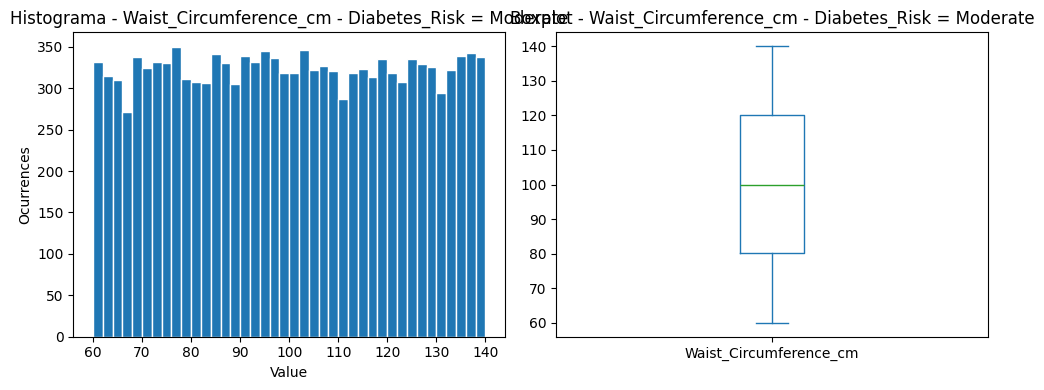

Blood_Glucose mean:  159.45979503350415
Blood_Glucose skewness:  0.023005614828504602
Blood_Glucose standart deviation:  52.12295525164378


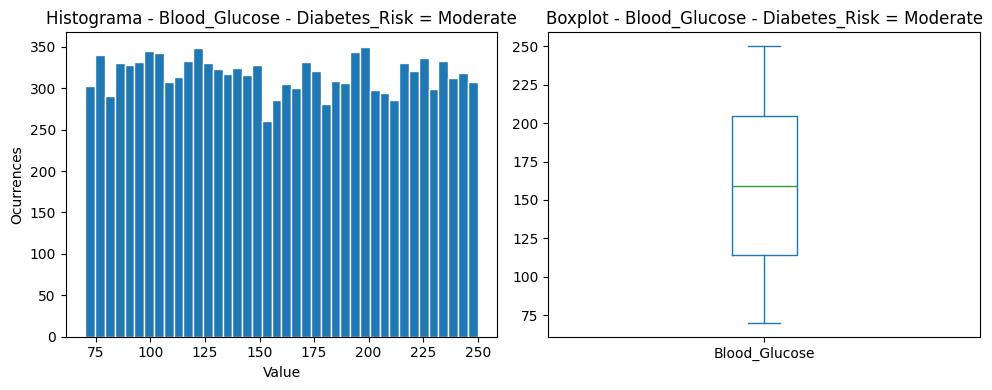

HbA1c mean:  7.5428847236746845
HbA1c skewness:  0.5124840673988207
HbA1c standart deviation:  2.418793209767586


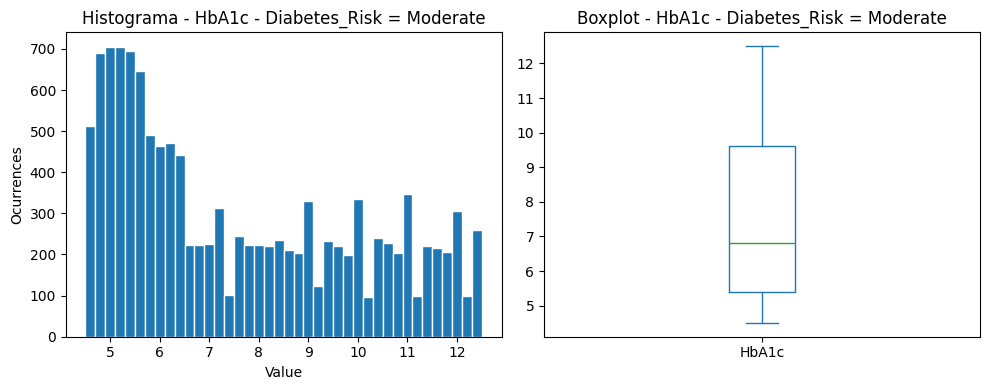

Fasting_Blood_Sugar mean:  115.81301692819046
Fasting_Blood_Sugar skewness:  0.919690865790795
Fasting_Blood_Sugar standart deviation:  42.642626722413


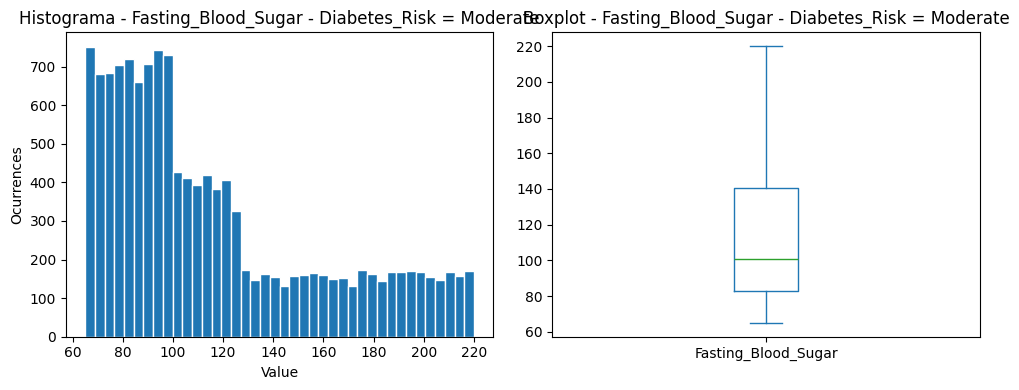

Insulin_Level mean:  23.60823220221071
Insulin_Level skewness:  -0.00846787305633875
Insulin_Level standart deviation:  12.409146614591064


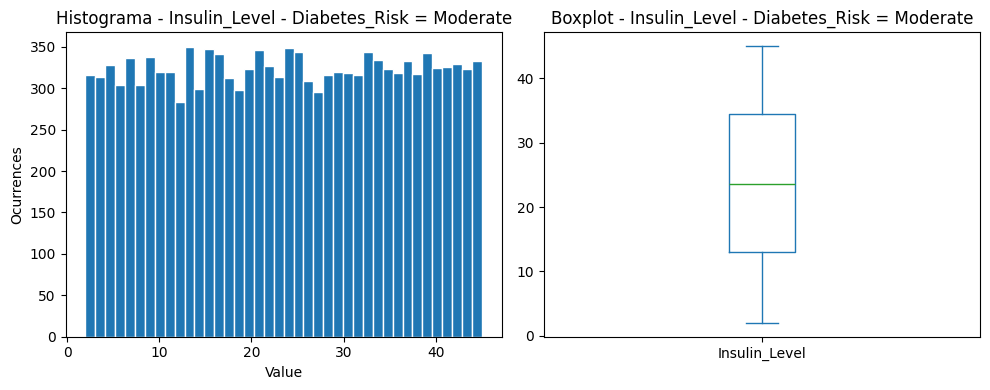

Blood_Pressure_Systolic mean:  134.7296900363299
Blood_Pressure_Systolic skewness:  0.26122554172448875
Blood_Pressure_Systolic standart deviation:  28.671722948220246


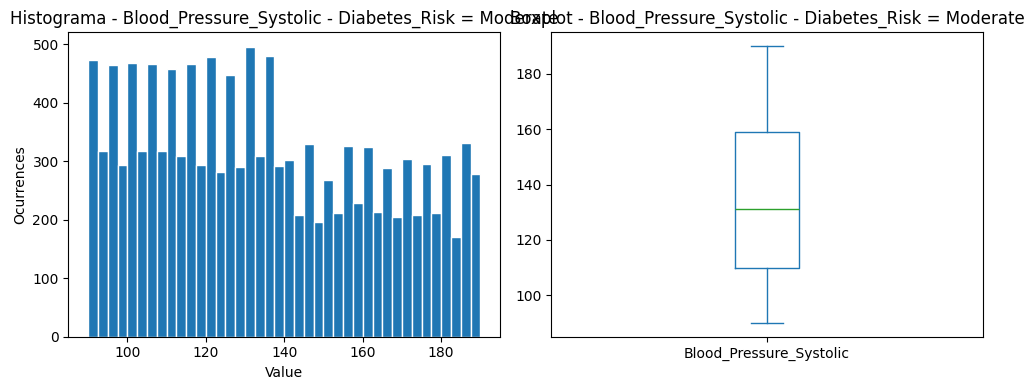

Blood_Pressure_Diastolic mean:  88.05828244569838
Blood_Pressure_Diastolic skewness:  0.1537164837411046
Blood_Pressure_Diastolic standart deviation:  17.53644066841788


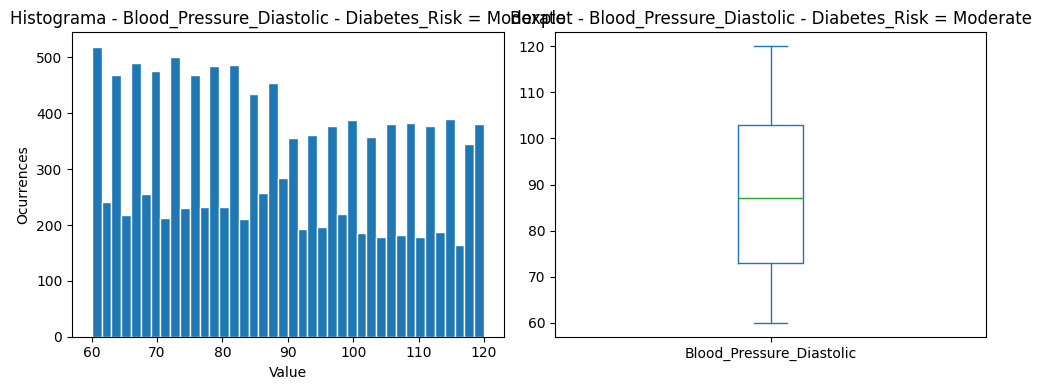

Total_Cholesterol mean:  211.82409714556061
Total_Cholesterol skewness:  0.2102397191427829
Total_Cholesterol standart deviation:  57.39561464423004


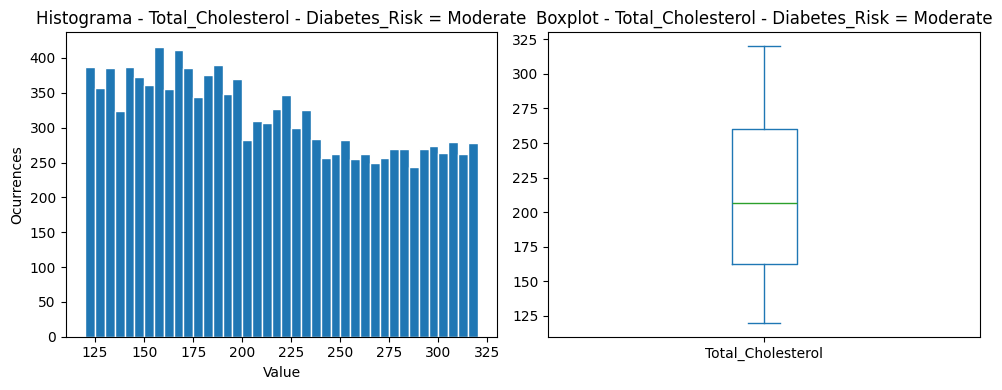

HDL mean:  57.25283332016122
HDL skewness:  0.009702390236015875
HDL standart deviation:  18.82456439606679


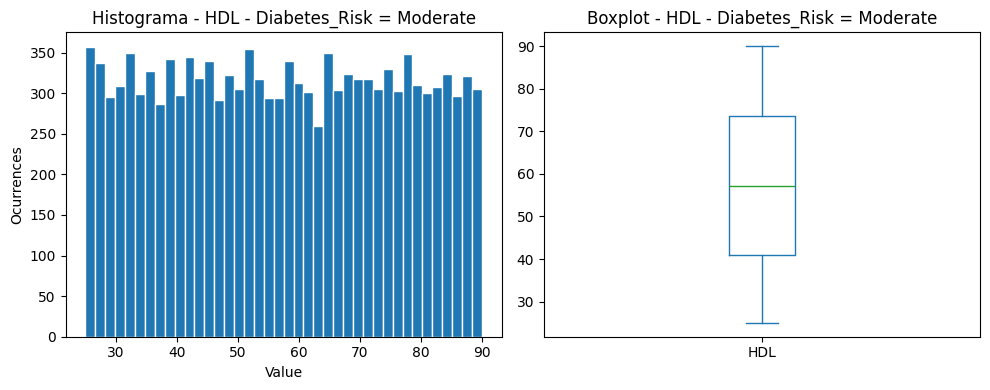

LDL mean:  135.347436099716
LDL skewness:  -0.009450103377554727
LDL standart deviation:  49.19137454793319


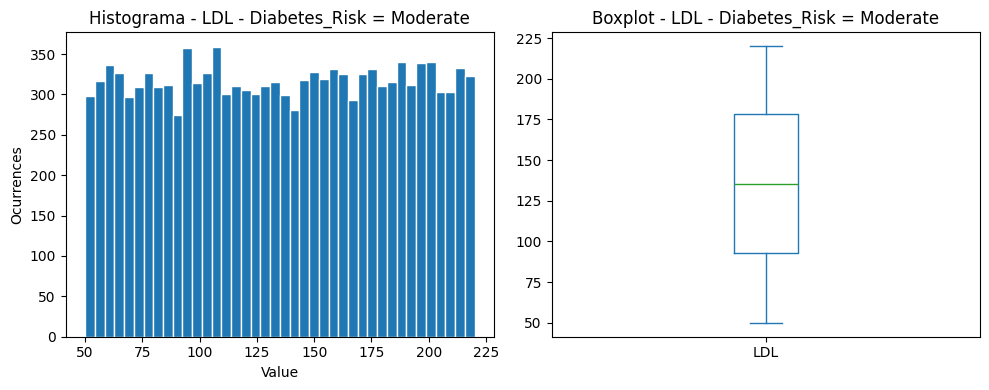

Triglycerides mean:  229.47304897314373
Triglycerides skewness:  -0.00020501071560111376
Triglycerides standart deviation:  98.4007942854385


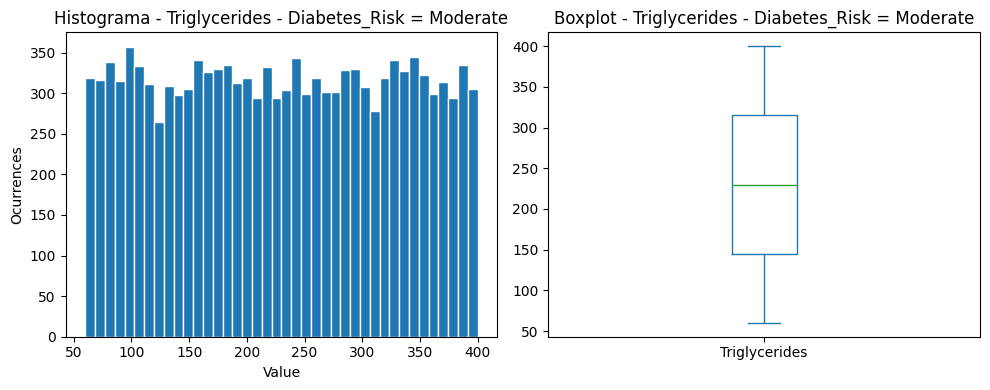

Heart_Rate mean:  85.09979129628198
Heart_Rate skewness:  -0.01226022922072178
Heart_Rate standart deviation:  20.430403168862757


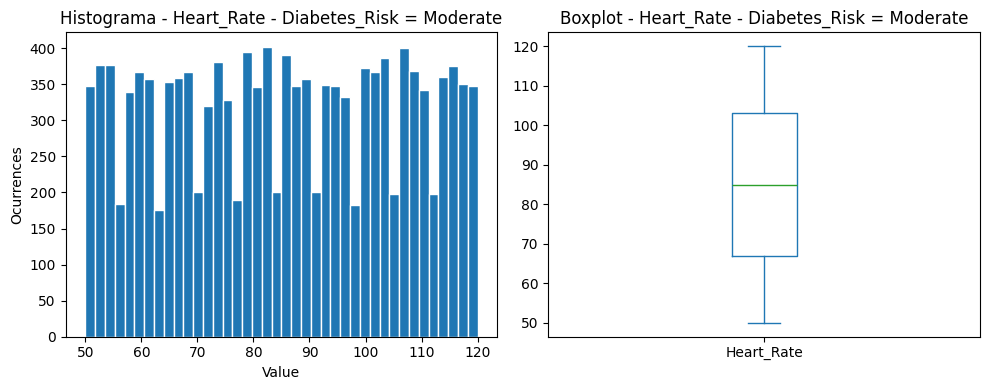

Exercise_Hours_Per_Week mean:  5.0154841301727595
Exercise_Hours_Per_Week skewness:  -0.02409308200299465
Exercise_Hours_Per_Week standart deviation:  2.864532307335952


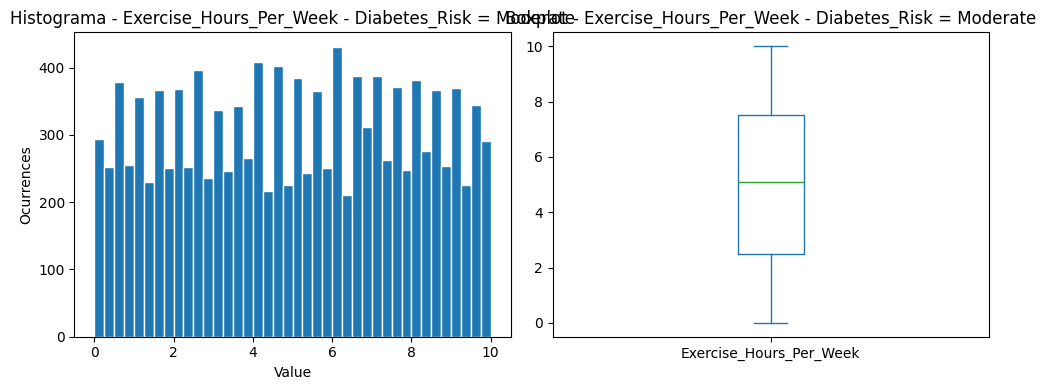

Daily_Walking_Minutes mean:  90.24214670201656
Daily_Walking_Minutes skewness:  0.0071366774529517465
Daily_Walking_Minutes standart deviation:  52.061121100238836


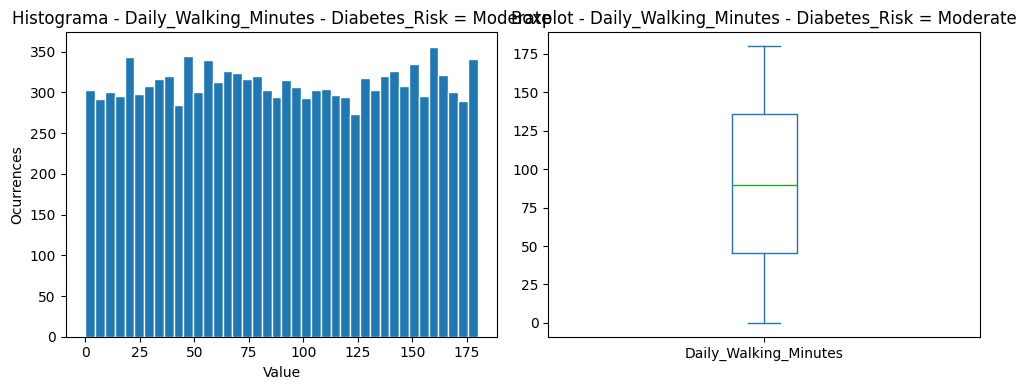

Sleep_Hours mean:  6.664362173038229
Sleep_Hours skewness:  -0.11176748072942422
Sleep_Hours standart deviation:  1.9970482800275242


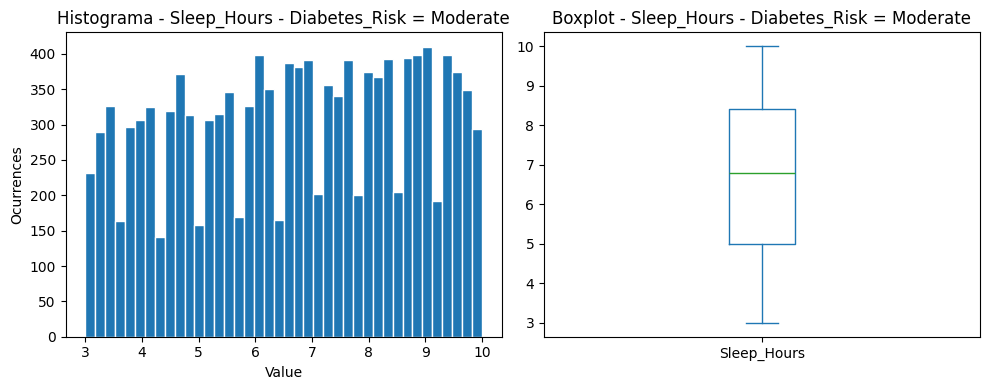

Daily_Water_Intake_L mean:  2.9795315760995593
Daily_Water_Intake_L skewness:  0.0180900637451141
Daily_Water_Intake_L standart deviation:  1.153709967199789


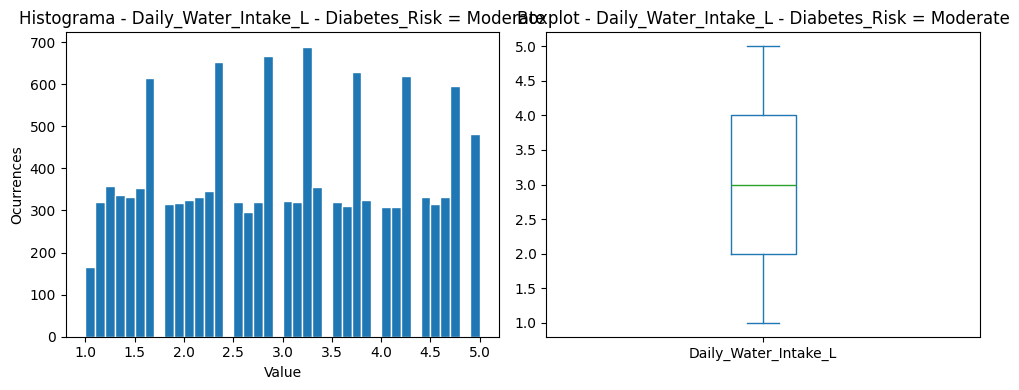

In [8]:
nome_preditores_quantitativos = preditores_quantitativos.columns

print('ANALISE CONDICIONAL NA CLASSE', classe, '\n')

for subgrupo, subtabela in preditores.groupby(classe):
    print('===== %s = %s  (N_l = %d) =====\n' % (classe, subgrupo, len(subtabela)))
    for column in nome_preditores_quantitativos:
        print_statistics(subtabela, column)
        plot_hist_and_box(subtabela, column, '- %s = %s' % (classe, subgrupo))

E aqui a mesma tabulação para a análise condicional: as D x L = 60 médias, desvios padrão e
assimetrias, uma linha por preditor e uma coluna por classe.

In [9]:
estatisticas = preditores.groupby(classe)[list(nome_preditores_quantitativos)].agg(['mean','std','skew'])

for estatistica, titulo in [('mean','MEDIAS'), ('std','DESVIOS PADRAO'), ('skew','ASSIMETRIAS')]:
    tabela = estatisticas.xs(estatistica, axis=1, level=1).T[['Low','Moderate','High']].round(3)
    print('===== %s CONDICIONAIS =====' % titulo)
    print(tabela.to_string())
    print()

===== MEDIAS CONDICIONAIS =====
Diabetes_Risk                 Low  Moderate     High
Age                        38.813    46.891   56.527
Height_cm                 173.663   171.758  169.354
Weight_kg                  75.677    81.769   89.613
BMI                        25.597    28.306   31.918
Waist_Circumference_cm    100.846   100.085   99.906
Blood_Glucose             159.012   159.460  160.074
HbA1c                       5.673     7.543    8.859
Fasting_Blood_Sugar        88.442   115.813  152.776
Insulin_Level              23.052    23.608   23.436
Blood_Pressure_Systolic   127.977   134.730  142.251
Blood_Pressure_Diastolic   85.549    88.058   90.797
Total_Cholesterol         200.409   211.824  223.375
HDL                        58.678    57.253   57.397
LDL                       135.038   135.347  134.897
Triglycerides             229.467   229.473  229.569
Heart_Rate                 85.362    85.100   85.130
Exercise_Hours_Per_Week     5.034     5.015    5.018
Daily_Walking_

Para responder diretamente a pergunta do enunciado sobre poder discriminativo ("são, sozinhos,
capazes de separar as classes?"), ordenamos os preditores pela distância entre a média da classe
mais alta e a da mais baixa, normalizada pelo desvio padrão do preditor. Quanto maior esse valor,
mais o preditor sozinho separa os grupos.

In [10]:
medias_por_classe = estatisticas.xs('mean', axis=1, level=1).T
separabilidade = ((medias_por_classe.max(axis=1) - medias_por_classe.min(axis=1))
                  / preditores_quantitativos.std()).sort_values(ascending=False).round(3)

print('Poder discriminativo de cada preditor (amplitude entre classes / desvio padrao):')
print(separabilidade.to_string())

Poder discriminativo de cada preditor (amplitude entre classes / desvio padrao):
Fasting_Blood_Sugar         1.440
HbA1c                       1.377
Age                         0.838
BMI                         0.614
Weight_kg                   0.569
Blood_Pressure_Systolic     0.489
Total_Cholesterol           0.397
Blood_Pressure_Diastolic    0.299
Height_cm                   0.298
Sleep_Hours                 0.165
HDL                         0.076
Daily_Water_Intake_L        0.059
Insulin_Level               0.045
Waist_Circumference_cm      0.041
Daily_Walking_Minutes       0.027
Blood_Glucose               0.020
Heart_Rate                  0.013
LDL                         0.009
Exercise_Hours_Per_Week     0.006
Triglycerides               0.001


# ANÁLISE BIVARIADA INCONDICIONAL

Com a análise monovariada feita, o próximo passo é olhar a relação entre os preditores dois a dois.
O `Patient_ID` já foi descartado lá atrás, então trabalhamos direto com os 20 preditores
quantitativos restantes.

In [11]:
preditores_sem_id = preditores_quantitativos
print(preditores_sem_id.columns)

Index(['Age', 'Height_cm', 'Weight_kg', 'BMI', 'Waist_Circumference_cm',
       'Blood_Glucose', 'HbA1c', 'Fasting_Blood_Sugar', 'Insulin_Level',
       'Blood_Pressure_Systolic', 'Blood_Pressure_Diastolic',
       'Total_Cholesterol', 'HDL', 'LDL', 'Triglycerides', 'Heart_Rate',
       'Exercise_Hours_Per_Week', 'Daily_Walking_Minutes', 'Sleep_Hours',
       'Daily_Water_Intake_L'],
      dtype='str')


Primeiro calculamos a correlação de Pearson entre todos os pares de preditores, mostrando tanto a tabela quanto a matriz como imagem (fica mais fácil de bater o olho e achar onde tem alguma relação linear mais forte, positiva ou negativa).

                               Age  Height_cm  Weight_kg       BMI  \
Age                       1.000000  -0.007902  -0.002954 -0.001118   
Height_cm                -0.007902   1.000000  -0.002391 -0.516150   
Weight_kg                -0.002954  -0.002391   1.000000  0.843427   
BMI                      -0.001118  -0.516150   0.843427  1.000000   
Waist_Circumference_cm   -0.000894   0.005995  -0.004478 -0.006322   
Blood_Glucose             0.000807   0.003425  -0.004092 -0.002679   
HbA1c                     0.010058  -0.000161   0.001444  0.000397   
Fasting_Blood_Sugar       0.007339   0.000975   0.001368 -0.000257   
Insulin_Level             0.003040   0.001941   0.009855  0.007222   
Blood_Pressure_Systolic   0.003125   0.006005  -0.001721 -0.008943   
Blood_Pressure_Diastolic  0.004961   0.002447  -0.003457 -0.004424   
Total_Cholesterol        -0.009734   0.005164  -0.000706 -0.002163   
HDL                       0.001956   0.004593   0.003635  0.001493   
LDL                 

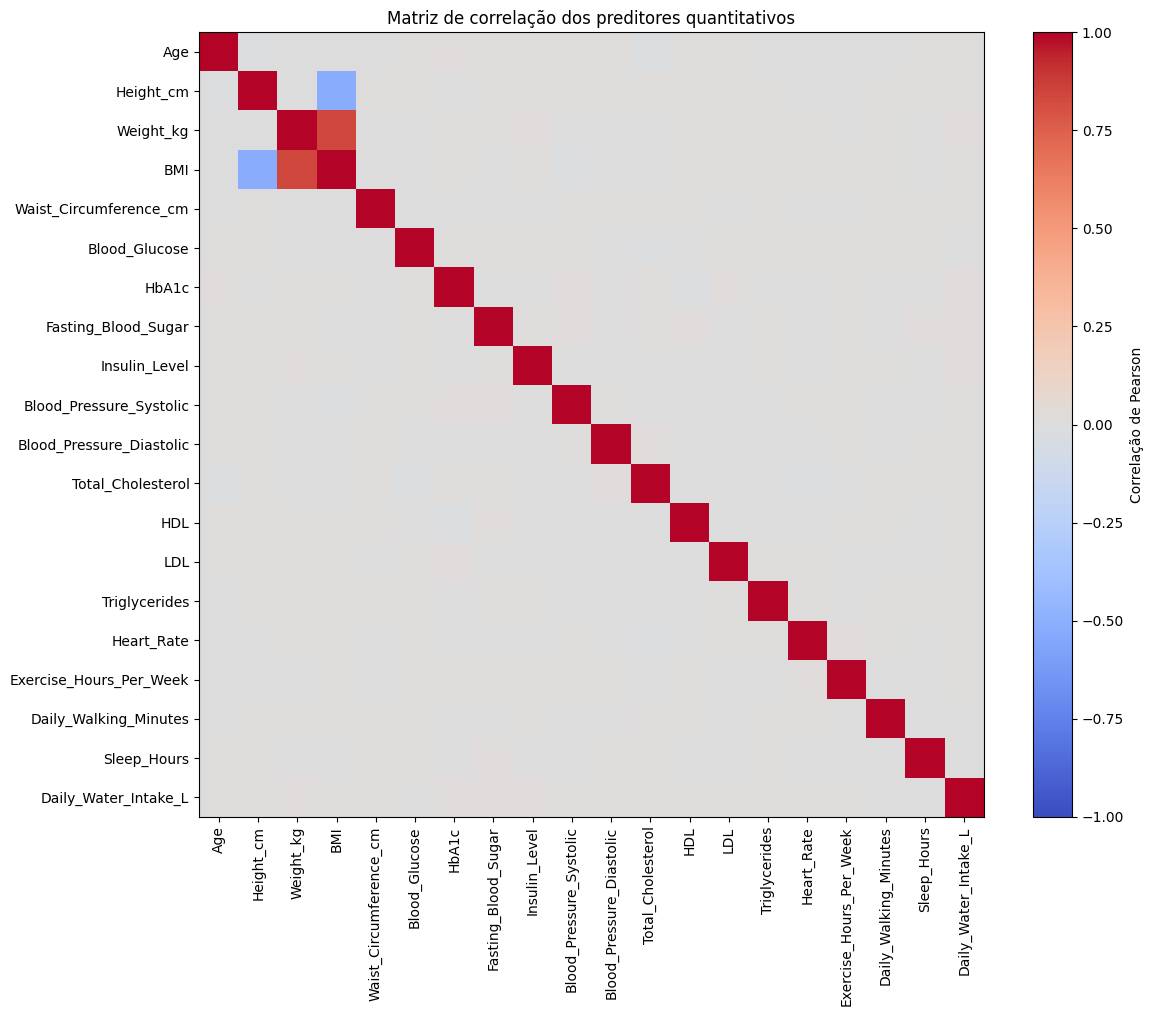

In [12]:
correlacao = preditores_sem_id.corr()
print(correlacao)

fig, ax = plt.subplots(figsize=(12, 10))
imagem = ax.imshow(correlacao, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(correlacao.columns)))
ax.set_yticks(range(len(correlacao.columns)))
ax.set_xticklabels(correlacao.columns, rotation=90)
ax.set_yticklabels(correlacao.columns)
fig.colorbar(imagem, ax=ax, label='Correlação de Pearson')
ax.set_title('Matriz de correlação dos preditores quantitativos')
plt.tight_layout()
salvar_figura('matriz_correlacao')
plt.show()

Agora os scatter plots de cada par de preditores. São 20 preditores, o que dá 190 pares possíveis;
plotar par por par deixaria o notebook gigante, então usamos o `scatter_matrix` do próprio pandas,
que monta tudo numa figura só. Os pontos são coloridos pela classe (`Low` em verde, `Moderate` em
laranja, `High` em vermelho), que é o que o enunciado pede para conseguir enxergar se algum par de
preditores separa os grupos.

Com 50.000 pontos em 400 painéis a figura fica pesada demais e as cores se sobrepõem a ponto de não
dar para enxergar nada, então sorteamos uma amostra aleatória de 5.000 observações só para este
gráfico. Como a amostragem é aleatória e uniforme, a estrutura visual das relações é preservada.

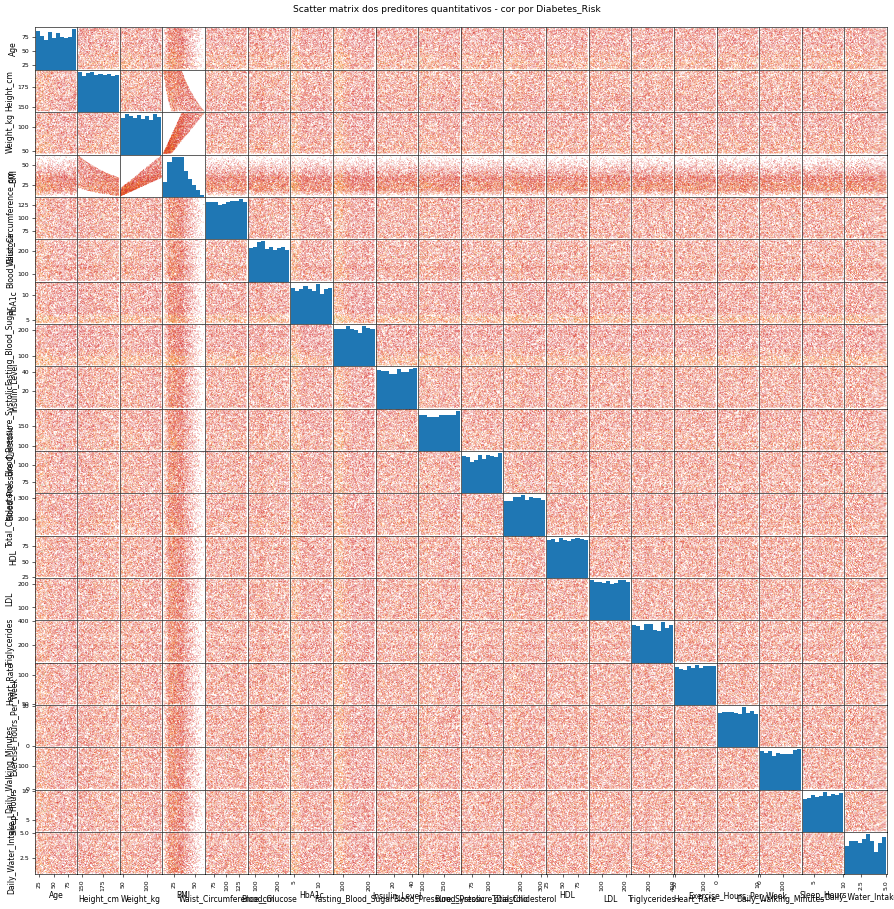

In [13]:
cores_por_classe = {'Low': 'tab:green', 'Moderate': 'tab:orange', 'High': 'tab:red'}

# o scatter_matrix descarta as linhas com NaN internamente, entao tiramos elas antes
# de sortear a amostra; senao o vetor de cores fica com tamanho diferente do de pontos
completos = preditores.dropna(subset=list(preditores_sem_id.columns))
amostra = completos.sample(n=3000, random_state=42) # amostra so para o grafico ficar legivel
cores_amostra = amostra[classe].map(cores_por_classe)

figura = pd.plotting.scatter_matrix(amostra[preditores_sem_id.columns], figsize=(20, 20),
                                    c=cores_amostra, alpha=0.4, s=5, diagonal='hist')
plt.suptitle('Scatter matrix dos preditores quantitativos - cor por %s' % classe, y=0.9)
salvar_figura('scatter_matrix', dpi=80) # versao em arquivo, para o artigo
plt.gcf().set_dpi(55) # reduz o peso da versao embutida no notebook
plt.show()


# ANÁLISE MULTIVARIADA - PCA

Pra fechar, fazemos a análise de componentes principais (PCA) na mão, sem usar sklearn nem nenhuma função de PCA pronta. A ideia é pegar os 20 preditores quantitativos e projetar eles em só 2 dimensões, mantendo o máximo de variância possível, pra dar pra visualizar tudo num scatter plot só. A única coisa que usamos do numpy é o cálculo de autovalor/autovetor (np.linalg.eigh) - o resto, padronização, matriz de covariância e a projeção, foi feito na mão mesmo, sem chamar nenhuma função de PCA.

In [14]:
import numpy as np

dados_pca = preditores_sem_id.dropna() # a matriz de covariancia nao pode ter NaN, e o dataset tem bastante linha com valor faltante
classes_pca = preditores.loc[dados_pca.index, classe]

print('Linhas antes do dropna: ', len(preditores_sem_id))
print('Linhas depois do dropna: ', len(dados_pca))

medias = dados_pca.mean()
desvios = dados_pca.std()
dados_padronizados = (dados_pca - medias) / desvios # padroniza pra media 0 e desvio padrao 1, ja que os preditores estao em escalas bem diferentes (BMI vai ate uns 50, Blood_Glucose passa de 200) e sem isso quem tem maior escala ia dominar a analise

matriz_covariancia = (dados_padronizados.T @ dados_padronizados) / (len(dados_padronizados) - 1)

autovalores, autovetores = np.linalg.eigh(matriz_covariancia)

ordem = np.argsort(autovalores)[::-1] # eigh devolve em ordem crescente, entao invertemos pra ficar do maior autovalor pro menor
autovalores = autovalores[ordem]
autovetores = autovetores[:, ordem]

print('Autovalores, do maior pro menor:')
print(autovalores)
print('Variancia explicada pelas 2 primeiras componentes: ', (autovalores[0] + autovalores[1]) / autovalores.sum())

Linhas antes do dropna:  50000
Linhas depois do dropna:  33689
Autovalores, do maior pro menor:
[1.99425291 1.03706444 1.03268402 1.02923559 1.02427663 1.01935477
 1.0116878  1.0086205  1.00617729 1.00127427 0.9988547  0.9942554
 0.98851539 0.98432015 0.98379914 0.97801802 0.97362502 0.96528875
 0.95637211 0.01232312]
Variancia explicada pelas 2 primeiras componentes:  0.15156586735337385


Com os autovetores em mãos, pegamos só os 2 primeiros (associados aos 2 maiores autovalores) e
projetamos os dados padronizados nessas 2 direções. É essa projeção que vira o scatter plot final,
de novo colorido pela classe `Diabetes_Risk`.

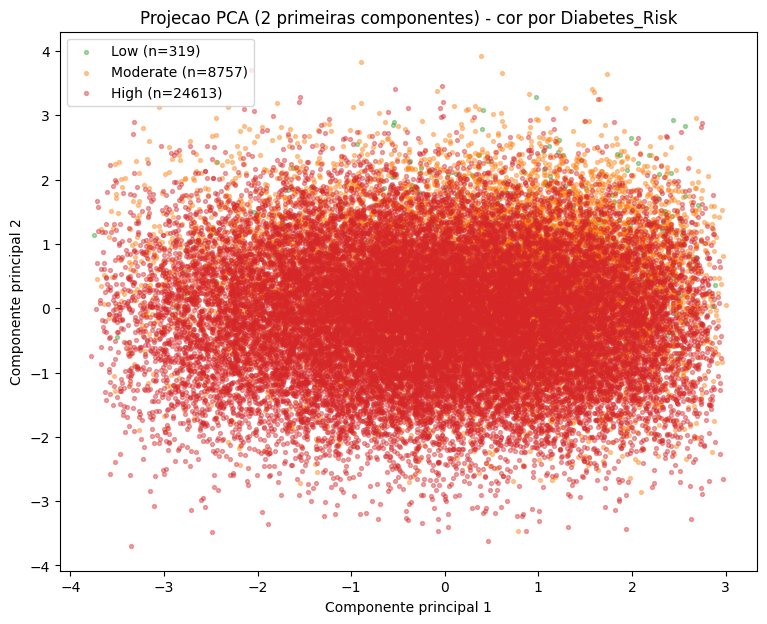

In [15]:
componentes_principais = autovetores[:, :2]
dados_projetados = dados_padronizados.values @ componentes_principais

plt.figure(figsize=(9, 7))
for nome_classe, cor in cores_por_classe.items():
    mascara = (classes_pca == nome_classe).values
    plt.scatter(dados_projetados[mascara, 0], dados_projetados[mascara, 1],
                c=cor, alpha=0.4, s=8, label='%s (n=%d)' % (nome_classe, mascara.sum()))
plt.xlabel('Componente principal 1')
plt.ylabel('Componente principal 2')
plt.title('Projecao PCA (2 primeiras componentes) - cor por %s' % classe)
plt.legend()
salvar_figura('pca_projecao')
plt.show()